# March Madness 2026 — NCAA Tournament Prediction Pipeline

**Competition:** [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026)  
**Objective:** Predict the probability that Team 1 beats Team 2 for every possible matchup in both the Men's and Women's 2026 NCAA basketball tournaments.  
**Metric:** Mean Squared Error (Brier score) — lower is better. Overconfident wrong predictions are heavily penalized.  
**Submission format:** `ID,Pred` where `ID = Season_Team1ID_Team2ID` (Team1ID < Team2ID) and `Pred ∈ [0, 1]`.

---

### Pipeline Overview

This notebook runs **end-to-end** — from downloading raw data to generating a submission CSV:

| Step | What | Why |
|------|------|-----|
| **0. Data Download** | Pull latest CSVs from Kaggle | Ensures we always train on the freshest data |
| **1. Feature Engineering** | Box scores → per-team season stats → matchup feature differences | Reduce ~100K game rows to ~30 meaningful features per team-pair |
| **2. Experiment Tracking** | Test 25+ model/feature combos with 3-year holdout validation | A change only counts if it helps on ≥2 of 3 holdout years |
| **3. Model Selection** | Compare LogReg, XGBoost, LightGBM; split M/W vs combined | Simple LogReg wins — dataset (~1,900 games) is too small for deep trees |
| **4. Final Submission** | Train on all 2010–2025 data, predict 2026, clip to [0.025, 0.975] | Conservative calibration prevents MSE blowups |

### Key Findings (from 25+ experiments)

1. **Elo ratings are the strongest single feature** — game-by-game dynamic ratings capture recency, opponent quality, and margin of victory
2. **Logistic Regression beats XGBoost/LightGBM** — only ~130 tournament games per year; trees overfit
3. **Seed difference is the #2 predictor** — the selection committee already encodes team strength
4. **Top features:** Elo, seed, point differential, offensive efficiency, win %, GLM quality
5. **Split M/W models beat combined** — women's tournament is more predictable (fewer upsets)
6. **SOS, shooting %, and coach experience are redundant** — they don't beat top features in multi-year validation
7. **Every new feature must earn its place** — validate on 3+ holdout years before adding

In [62]:
import sys, os
import importlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.model_selection import GroupKFold
import xgboost as xgb
import lightgbm as lgb

sys.path.insert(0, '..')
from src import data_loader, features, models, utils
# Reload modules to pick up any code changes
for mod in [data_loader, features, models, utils]:
    importlib.reload(mod)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

print('Libraries loaded.')

Libraries loaded.


---
## Step 0: Download Latest Data from Kaggle

Every run starts by pulling the latest competition data. This ensures we always have the most recent regular season results, tournament outcomes, and submission templates. The Kaggle CLI must be installed and authenticated (`~/.kaggle/kaggle.json`).

> **Note:** If data was recently downloaded and hasn't changed, this step completes quickly.

In [63]:
# Download fresh data from Kaggle (overwrites existing CSVs)
data_loader.download_latest_data()

# Verify key files exist
from pathlib import Path
data_dir = Path('..') / 'data'
expected = [
    'MRegularSeasonDetailedResults.csv', 'WRegularSeasonDetailedResults.csv',
    'MNCAATourneyDetailedResults.csv', 'WNCAATourneyDetailedResults.csv',
    'MNCAATourneySeeds.csv', 'WNCAATourneySeeds.csv',
    'MMasseyOrdinals.csv', 'SampleSubmissionStage2.csv',
]
for f in expected:
    status = '✓' if (data_dir / f).exists() else '✗ MISSING'
    print(f"  {status}  {f}")

csv_count = len(list(data_dir.glob('*.csv')))
print(f"\nTotal CSV files: {csv_count}")

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
⚠️  Kaggle download failed (exit 1): 
Continuing with existing local data...
  ✓  MRegularSeasonDetailedResults.csv
  ✓  WRegularSeasonDetailedResults.csv
  ✓  MNCAATourneyDetailedResults.csv
  ✓  WNCAATourneyDetailedResults.csv
  ✓  MNCAATourneySeeds.csv
  ✓  WNCAATourneySeeds.csv
  ✓  MMasseyOrdinals.csv
  ✓  SampleSubmissionStage2.csv

Total CSV files: 35


---
## Experiment Tracker

Every model variant we try gets logged here. We track MSE on **three holdout years** (2023, 2024, 2025) so we can see if an improvement is real or just got lucky on one year. A change only counts as an improvement if it helps on **at least 2 of 3** holdout years.

**Why three years?** With only ~130 tournament games per year, a single holdout year can be noisy — one fluky upset can swing MSE by 0.01+. Three-year validation smooths this out.

In [64]:
# Experiment tracker — every model run gets logged here
experiments = []

def log_experiment(name, description, val_results, model_obj=None):
    """Log a model experiment with MSE on each holdout year.
    
    val_results: dict of {year: {'mse': float, 'accuracy': float, 'n_games': int}}
    """
    entry = {
        'name': name,
        'description': description,
        'model': model_obj,
    }
    mses = []
    for year, metrics in val_results.items():
        entry[f'MSE_{year}'] = metrics['mse']
        entry[f'Acc_{year}'] = metrics.get('accuracy', None)
        mses.append(metrics['mse'])
    entry['MSE_avg'] = np.mean(mses)
    experiments.append(entry)
    
    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  {description}")
    print(f"{'='*60}")
    for year, metrics in val_results.items():
        acc_str = f", Acc={metrics['accuracy']:.1%}" if 'accuracy' in metrics else ''
        print(f"  {year}: MSE={metrics['mse']:.6f}{acc_str}  ({metrics['n_games']} games)")
    print(f"  Average MSE: {entry['MSE_avg']:.6f}")
    print(f"{'='*60}")

def show_leaderboard():
    """Display all experiments ranked by average MSE."""
    if not experiments:
        print("No experiments logged yet.")
        return
    cols = ['name', 'description']
    cols += [c for c in experiments[0] if c.startswith('MSE_')]
    df = pd.DataFrame(experiments)[cols].sort_values('MSE_avg')
    print("\n" + "="*80)
    print("  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)")
    print("="*80)
    print(df.to_string(index=False))
    return df

HOLDOUT_YEARS = [2023, 2024, 2025]
print(f"Holdout validation years: {HOLDOUT_YEARS}")

Holdout validation years: [2023, 2024, 2025]


---
## Step 1: Load Data & Engineer Features

We load the freshly downloaded CSVs, then transform raw game-level box scores into per-team season statistics. The pipeline:

```
Raw game data (W/L format)
  → prepare_game_data()          # Convert to symmetric T1/T2 rows (2 rows per game)
  → compute_season_stats()       # Per-game averages: FGM, TO, Rebounds, etc.
  → compute_win_pct()            # Season record
  → compute_efficiency()         # Points per possession (pace-independent)
  → compute_last14_momentum()    # Late-season form
  → build_team_features()        # Merge all into one table keyed on (Season, TeamID)
  → create_matchup_df()          # Join features for both teams in each matchup
  → compute_difference_features() # Diff_X = T1_X − T2_X (what the model sees)
```

We filter to **2010+ seasons** because women's detailed stats start in 2010, and we **skip 2020** (COVID cancellation).

In [65]:
# Load raw data
regular_season = data_loader.load_regular_season()
tourney_results = data_loader.load_tourney_results()
seeds = data_loader.load_tourney_seeds()
teams = data_loader.load_teams()
sample_sub = data_loader.load_sample_submission(stage=2)

# Prepare symmetric game data (2010+)
valid = utils.valid_seasons(min_season=2010, max_season=2026)
rs_filtered = regular_season[regular_season['Season'].isin(valid)]
game_data = features.prepare_game_data(rs_filtered)

# Compute all per-team season stats
season_stats = features.compute_season_stats(game_data)
win_pct = features.compute_win_pct(game_data)
efficiency = features.compute_efficiency(game_data)
momentum = features.compute_last14_momentum(game_data)

print(f"Game data: {len(game_data):,} rows")
print(f"Teams per season: ~{season_stats.groupby('Season').size().mean():.0f}")
print(f"Seasons: {sorted(game_data['Season'].unique())}")

Game data: 327,414 rows
Teams per season: ~704
Seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [66]:
# Build tournament matchups with T1_TeamID < T2_TeamID
tourney = tourney_results[tourney_results['Season'].isin(valid)].copy()
tourney = tourney[~tourney['Season'].isin([2020, 2026])].copy()

tourney['T1_TeamID'] = np.minimum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T2_TeamID'] = np.maximum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T1_Win'] = (tourney['WTeamID'] == tourney['T1_TeamID']).astype(int)

for yr in HOLDOUT_YEARS:
    n = (tourney['Season'] == yr).sum()
    print(f"  {yr}: {n} tournament games")
print(f"  Total: {len(tourney)} games")

  2023: 134 tournament games
  2024: 134 tournament games
  2025: 134 tournament games
  Total: 1962 games


### Data Exploration — What Are We Working With?

Let's understand the scale and structure of the data before engineering features. Key questions:
- How many teams, games, seasons?
- How does the training data break down between men's and women's games?
- What does the tournament target variable (T1_Win) look like?

In [67]:
# Data summary
print("="*60)
print("  DATA OVERVIEW")
print("="*60)

# Regular season
n_men_rs = len(regular_season[regular_season['WTeamID'] < 3000])
n_women_rs = len(regular_season[regular_season['WTeamID'] >= 3000])
print(f"\nRegular Season Games:")
print(f"  Men's:   {n_men_rs:,} games ({regular_season[regular_season['WTeamID'] < 3000]['Season'].nunique()} seasons)")
print(f"  Women's: {n_women_rs:,} games ({regular_season[regular_season['WTeamID'] >= 3000]['Season'].nunique()} seasons)")

# Tournament
n_men_t = len(tourney[tourney['T1_TeamID'] < 3000])
n_women_t = len(tourney[tourney['T1_TeamID'] >= 3000])
print(f"\nTournament Games (training set):")
print(f"  Men's:   {n_men_t} games")
print(f"  Women's: {n_women_t} games")
print(f"  Total:   {len(tourney)} games ← THIS is what we train on")
print(f"  ⚠️  Only ~{len(tourney)//len(HOLDOUT_YEARS + list(range(2010,2023))):.0f} games/year — very small!")

# Target balance
t1_win_rate = tourney['T1_Win'].mean()
print(f"\nTarget (T1_Win): {t1_win_rate:.1%} win rate")
print(f"  (Should be ~50% since T1/T2 are ordered by ID, not strength)")

# Seasons breakdown
print(f"\nSeasons used: {sorted(tourney['Season'].unique())}")
print(f"Holdout years: {HOLDOUT_YEARS}")

  DATA OVERVIEW

Regular Season Games:
  Men's:   122,775 games (24 seasons)
  Women's: 85,505 games (17 seasons)

Tournament Games (training set):
  Men's:   1001 games
  Women's: 961 games
  Total:   1962 games ← THIS is what we train on
  ⚠️  Only ~122 games/year — very small!

Target (T1_Win): 51.0% win rate
  (Should be ~50% since T1/T2 are ordered by ID, not strength)

Seasons used: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Holdout years: [2023, 2024, 2025]


---
## Step 2: Multi-Year Holdout Validation Framework

The core idea: **don't trust a single holdout year**. A model that looks great on 2025 alone may have gotten lucky.

Our validation protocol:
1. **Pick a holdout year** (e.g., 2025)
2. **Train on all years before it** (2010–2024, excluding 2020 COVID cancellation)
3. **Predict and evaluate** on the holdout year's tournament games
4. **Evaluate on holdout year** — measure MSE on tournament predictions
5. **Repeat for 2023, 2024, 2025** — average MSE across all three

This gives us a reliable estimate of generalization, not just a lucky year.

Two experiment runners are defined below:
- **`run_experiment()`** — trains a single model on all data (combined M+W or filtered)
- **`run_split_experiment()`** — trains separate men's and women's models, combines predictions

In [68]:
def run_experiment(name, description, feature_names, matchup_df, 
                   model_type='logreg', model_params=None,
                   holdout_years=HOLDOUT_YEARS):
    """Train/evaluate a model on multiple holdout years.
    
    For each holdout year:
      - Train on all years BEFORE the holdout (no future leakage)
      - Predict and evaluate on the holdout year
    
    Args:
        name: Short experiment name for the leaderboard.
        description: Longer description of what's being tested.
        feature_names: List of Diff_* column names to use.
        matchup_df: DataFrame with T1_Win, Season, and feature columns.
        model_type: 'logreg', 'xgb', or 'lgbm'.
        model_params: Override default hyperparameters.
        holdout_years: Which years to hold out for evaluation.
    
    Returns:
        val_results: dict of {year: {'mse', 'accuracy', 'n_games'}}.
    """
    val_results = {}
    
    for hold_year in holdout_years:
        train_mask = (matchup_df['Season'] < hold_year) & (~matchup_df['Season'].isin([2020]))
        val_mask = matchup_df['Season'] == hold_year
        
        X_tr = matchup_df.loc[train_mask, feature_names].fillna(0).values
        y_tr = matchup_df.loc[train_mask, 'T1_Win'].values
        X_va = matchup_df.loc[val_mask, feature_names].fillna(0).values
        y_va = matchup_df.loc[val_mask, 'T1_Win'].values
        
        if len(X_va) == 0:
            continue
        
        if model_type == 'logreg':
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)
            params = model_params or {'C': 1.0, 'max_iter': 1000}
            clf = LogisticRegression(**params, random_state=42)
            clf.fit(X_tr, y_tr)
            preds = clf.predict_proba(X_va)[:, 1]
            
        elif model_type == 'xgb':
            params = model_params or {
                'objective': 'binary:logistic', 'eval_metric': 'logloss',
                'eta': 0.05, 'max_depth': 3, 'subsample': 0.8,
                'colsample_bytree': 0.8, 'min_child_weight': 20,
                'verbosity': 0, 'seed': 42,
            }
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dval = xgb.DMatrix(X_va, label=y_va)
            model = xgb.train(params, dtrain, num_boost_round=500,
                            evals=[(dval, 'val')], early_stopping_rounds=50,
                            verbose_eval=0)
            preds = model.predict(dval)
            
        elif model_type == 'lgbm':
            params = model_params or {
                'objective': 'binary', 'metric': 'binary_logloss',
                'learning_rate': 0.05, 'num_leaves': 16, 'max_depth': 3,
                'subsample': 0.8, 'colsample_bytree': 0.8,
                'min_child_samples': 20, 'verbose': -1, 'seed': 42,
            }
            dtrain = lgb.Dataset(X_tr, label=y_tr)
            dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
            model = lgb.train(params, dtrain, num_boost_round=500,
                            valid_sets=[dval],
                            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            preds = model.predict(X_va)
        
        preds = np.clip(preds, 0.025, 0.975)
        mse = mean_squared_error(y_va, preds)
        acc = (np.round(preds) == y_va).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(y_va)}
    
    log_experiment(name, description, val_results)
    return val_results

print("Experiment runner ready.")

Experiment runner ready.


In [69]:
def run_split_experiment(name, description, 
                         men_features, men_model_type, men_params,
                         women_features, women_model_type, women_params,
                         men_df, women_df, holdout_years=HOLDOUT_YEARS):
    """Evaluate a split M/W strategy across holdout years.
    
    Trains separate models for men's and women's games, then combines
    predictions for an overall MSE score. This lets us tune each gender's
    model independently.
    
    Args:
        name: Short experiment name for the leaderboard.
        description: Longer description of what's being tested.
        men_features: List of Diff_* column names for men's model.
        men_model_type: 'logreg' or 'xgb'.
        men_params: Override default hyperparameters for men.
        women_features: List of Diff_* column names for women's model.
        women_model_type: 'logreg' or 'xgb'.
        women_params: Override default hyperparameters for women.
        men_df: DataFrame with men's tournament matchups.
        women_df: DataFrame with women's tournament matchups.
        holdout_years: Which years to hold out for evaluation.
    
    Returns:
        val_results: dict of {year: {'mse', 'accuracy', 'n_games'}}.
    """
    val_results = {}
    
    for hold_year in holdout_years:
        all_preds = []
        all_labels = []
        
        for df, feats, mtype, mparams, label in [
            (men_df, men_features, men_model_type, men_params, 'M'),
            (women_df, women_features, women_model_type, women_params, 'W'),
        ]:
            train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
            val_mask = df['Season'] == hold_year
            
            X_tr = df.loc[train_mask, feats].fillna(0).values
            y_tr = df.loc[train_mask, 'T1_Win'].values
            X_va = df.loc[val_mask, feats].fillna(0).values
            y_va = df.loc[val_mask, 'T1_Win'].values
            
            if len(X_va) == 0:
                continue
            
            if mtype == 'logreg':
                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr)
                X_va = scaler.transform(X_va)
                params = mparams or {'C': 1.0, 'max_iter': 1000}
                clf = LogisticRegression(**params, random_state=42)
                clf.fit(X_tr, y_tr)
                preds = clf.predict_proba(X_va)[:, 1]
            elif mtype == 'xgb':
                params = mparams or xgb_conservative
                dtrain = xgb.DMatrix(X_tr, label=y_tr)
                dval = xgb.DMatrix(X_va, label=y_va)
                model = xgb.train(params, dtrain, num_boost_round=500,
                                evals=[(dval, 'val')], early_stopping_rounds=50,
                                verbose_eval=0)
                preds = model.predict(dval)
            
            preds = np.clip(preds, 0.025, 0.975)
            all_preds.extend(preds)
            all_labels.extend(y_va)
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        mse = mean_squared_error(all_labels, all_preds)
        acc = (np.round(all_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    
    log_experiment(name, description, val_results)
    return val_results

print("Split experiment runner ready.")

Split experiment runner ready.


---
## Step 3: Run Experiments

### Experiment 1: Seed-Only Baseline

How well can we do with **just seed difference**? This is the floor — if we can't beat this, our features aren't adding value. The NCAA selection committee already considers record, strength of schedule, and eye-test when assigning seeds, so seed difference is a surprisingly strong predictor on its own.

In [70]:
# Build features — seeds only
tf_seeds = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds
)
tourney_f = features.create_matchup_df(tourney, tf_seeds)
tourney_f, diff_cols = features.compute_difference_features(tourney_f)

# Experiment 1a: Just seed difference
run_experiment(
    'Seed Only (LR)', 
    'LogReg on Diff_seed only',
    ['Diff_seed'], tourney_f, 'logreg'
)


  Experiment: Seed Only (LR)
  LogReg on Diff_seed only
  2023: MSE=0.190180, Acc=69.4%  (134 games)
  2024: MSE=0.164201, Acc=76.1%  (134 games)
  2025: MSE=0.143248, Acc=79.9%  (134 games)
  Average MSE: 0.165876


{2023: {'mse': 0.19017996355932132,
  'accuracy': np.float64(0.6940298507462687),
  'n_games': 134},
 2024: {'mse': 0.16420080867126471,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 134},
 2025: {'mse': 0.14324773615606862,
  'accuracy': np.float64(0.7985074626865671),
  'n_games': 134}}

---
## Experiment 2: Core Features (What Won Phase 1)

The logistic regression feature importance showed **seed + point diff + offensive efficiency + win %** as the big 4. Let's test combinations to see which subset is best.

In [71]:
# Experiment 2a: Top 4 features from Phase 1
top4 = ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct']
run_experiment(
    'Top4 (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct',
    top4, tourney_f, 'logreg'
)


  Experiment: Top4 (LR)
  LogReg on seed + PointDiff + OffEff + WinPct
  2023: MSE=0.181327, Acc=73.9%  (134 games)
  2024: MSE=0.166476, Acc=73.9%  (134 games)
  2025: MSE=0.139637, Acc=83.6%  (134 games)
  Average MSE: 0.162480


{2023: {'mse': 0.18132729506271003,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2024: {'mse': 0.16647605830090106,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13963727017279837,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [72]:
# Experiment 2b: Top4 + defensive efficiency + momentum
top6 = top4 + ['Diff_DefEff', 'Diff_win_ratio_14d']
run_experiment(
    'Top6 (LR)',
    'LogReg on top4 + DefEff + momentum',
    top6, tourney_f, 'logreg'
)


  Experiment: Top6 (LR)
  LogReg on top4 + DefEff + momentum
  2023: MSE=0.181954, Acc=73.9%  (134 games)
  2024: MSE=0.166526, Acc=74.6%  (134 games)
  2025: MSE=0.139167, Acc=83.6%  (134 games)
  Average MSE: 0.162549


{2023: {'mse': 0.18195423916334635,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2024: {'mse': 0.16652566358195933,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13916741165934132,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [73]:
# Experiment 2c: All difference features (what we ran in Phase 1 of 03_modeling)
all_diff = [f for f in diff_cols if tourney_f[f].notna().mean() > 0.9]
run_experiment(
    'All Diff (LR)',
    f'LogReg on all {len(all_diff)} diff features',
    all_diff, tourney_f, 'logreg'
)


  Experiment: All Diff (LR)
  LogReg on all 20 diff features
  2023: MSE=0.188309, Acc=73.1%  (134 games)
  2024: MSE=0.169386, Acc=71.6%  (134 games)
  2025: MSE=0.144699, Acc=81.3%  (134 games)
  Average MSE: 0.167465


{2023: {'mse': 0.18830898749603533,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16938638528740696,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 134},
 2025: {'mse': 0.1446993871641639,
  'accuracy': np.float64(0.8134328358208955),
  'n_games': 134}}

---
## Experiment 3: XGBoost & LightGBM (Shallow & Constrained)

The lesson from Phase 1 was that XGBoost overfits with default settings. With only ~1,900 total tournament games and ~130 per year, gradient boosting has very limited signal to work with. Let's constrain it aggressively:
- **max_depth=2** (very shallow — can only learn simple interactions like "seed × point diff")
- **min_child_weight=30** (need 30+ samples per leaf — prevents fitting to noise)
- **Only top 4-6 features** (less room to overfit)

The idea: use tree models' ability to find non-linear interactions (e.g., seed matters more when point differentials are close), but don't give them enough rope to hang themselves.

In [74]:
# Experiment 3a: Shallow XGBoost on top 4 features
xgb_conservative = {
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'eta': 0.03, 'max_depth': 2, 'subsample': 0.7,
    'colsample_bytree': 1.0, 'min_child_weight': 30,
    'gamma': 5, 'verbosity': 0, 'seed': 42,
}

run_experiment(
    'Top4 (XGB shallow)',
    'XGBoost depth=2, min_child=30 on top4',
    top4, tourney_f, 'xgb', xgb_conservative
)


  Experiment: Top4 (XGB shallow)
  XGBoost depth=2, min_child=30 on top4
  2023: MSE=0.182052, Acc=70.9%  (134 games)
  2024: MSE=0.160572, Acc=73.9%  (134 games)
  2025: MSE=0.143740, Acc=82.1%  (134 games)
  Average MSE: 0.162121


{2023: {'mse': 0.18205226957798004,
  'accuracy': np.float64(0.7089552238805971),
  'n_games': 134},
 2024: {'mse': 0.16057217121124268,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.14373955130577087,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [75]:
# Experiment 3b: Shallow XGBoost on top 6
run_experiment(
    'Top6 (XGB shallow)',
    'XGBoost depth=2, min_child=30 on top6',
    top6, tourney_f, 'xgb', xgb_conservative
)


  Experiment: Top6 (XGB shallow)
  XGBoost depth=2, min_child=30 on top6
  2023: MSE=0.183086, Acc=72.4%  (134 games)
  2024: MSE=0.159119, Acc=74.6%  (134 games)
  2025: MSE=0.142754, Acc=80.6%  (134 games)
  Average MSE: 0.161653


{2023: {'mse': 0.1830863654613495,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.15911850333213806,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.1427539438009262,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 134}}

In [76]:
# Experiment 3c: Shallow LightGBM on top 6
lgb_conservative = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'learning_rate': 0.03, 'num_leaves': 8, 'max_depth': 2,
    'subsample': 0.7, 'colsample_bytree': 1.0,
    'min_child_samples': 30, 'verbose': -1, 'seed': 42,
}

run_experiment(
    'Top6 (LGBM shallow)',
    'LightGBM depth=2, min_child=30 on top6',
    top6, tourney_f, 'lgbm', lgb_conservative
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[238]	valid_0's binary_logloss: 0.538348
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[239]	valid_0's binary_logloss: 0.486295
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[498]	valid_0's binary_logloss: 0.436246

  Experiment: Top6 (LGBM shallow)
  LightGBM depth=2, min_child=30 on top6
  2023: MSE=0.182140, Acc=73.1%  (134 games)
  2024: MSE=0.162536, Acc=73.9%  (134 games)
  2025: MSE=0.143271, Acc=79.9%  (134 games)
  Average MSE: 0.162649


{2023: {'mse': 0.18213990260864635,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.1625364330535013,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.14327054819045776,
  'accuracy': np.float64(0.7985074626865671),
  'n_games': 134}}

---
### Experiment 4: GLM Team Quality

We fit a regularized logistic regression with team indicators on regular season game outcomes (restricted to tournament-eligible teams). The resulting coefficients measure each team's "quality" — essentially a simplified Elo/power rating. Z-score normalized so values range ~[-3, +3].

**Previous bug:** Without L2 regularization, coefficients exploded to 1e16. Now fixed with `alpha=0.1, L1_wt=0.0`.

In [77]:
# Compute GLM quality with the fixed regularized version
print("Computing GLM team quality (regularized)...")
quality = features.compute_team_quality(game_data, seeds)
print(f"Quality range: [{quality['quality'].min():.2f}, {quality['quality'].max():.2f}]")
print(f"Quality std: {quality['quality'].std():.2f} (should be ~1.0 if z-scored)")

# Top 5 per recent seasons
for yr in [2024, 2025]:
    top = quality[quality['Season'] == yr].nlargest(5, 'quality')
    top['name'] = top['TeamID'].apply(utils.team_name)
    print(f"\nTop 5 quality ({yr}): {list(top['name'])}")

Computing GLM team quality (regularized)...
Quality range: [-2.61, 4.95]
Quality std: 1.00 (should be ~1.0 if z-scored)

Top 5 quality (2024): ['South Carolina', 'Purdue', 'Iowa', 'LSU', 'Houston']

Top 5 quality (2025): ['UCLA', 'South Carolina', 'Auburn', 'Texas', 'USC']


In [78]:
# Rebuild features with quality
tf_quality = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds, quality=quality
)
tourney_q = features.create_matchup_df(tourney, tf_quality)
tourney_q, diff_cols_q = features.compute_difference_features(tourney_q)

# Experiment 4a: Top4 + quality
top4q = top4 + ['Diff_quality']
run_experiment(
    'Top4+Quality (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct + quality',
    top4q, tourney_q, 'logreg'
)


  Experiment: Top4+Quality (LR)
  LogReg on seed + PointDiff + OffEff + WinPct + quality
  2023: MSE=0.184646, Acc=73.1%  (134 games)
  2024: MSE=0.165846, Acc=74.6%  (134 games)
  2025: MSE=0.137555, Acc=84.3%  (134 games)
  Average MSE: 0.162682


{2023: {'mse': 0.18464569332065714,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.1658459636728331,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13755506130324935,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [79]:
# Experiment 4b: Top4 + quality with shallow XGBoost
run_experiment(
    'Top4+Quality (XGB)',
    'XGBoost depth=2 on top4 + quality',
    top4q, tourney_q, 'xgb', xgb_conservative
)


  Experiment: Top4+Quality (XGB)
  XGBoost depth=2 on top4 + quality
  2023: MSE=0.183022, Acc=72.4%  (134 games)
  2024: MSE=0.158927, Acc=75.4%  (134 games)
  2025: MSE=0.144645, Acc=78.4%  (134 games)
  Average MSE: 0.162198


{2023: {'mse': 0.1830216348171234,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.1589270979166031,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.14464546740055084,
  'accuracy': np.float64(0.7835820895522388),
  'n_games': 134}}

---
### Experiment 5: Massey Ordinals (Men-Only, Properly Handled)

Massey Ordinals are 3rd-party computer rankings (POM, SAG, MOR, DOL, COL). They're **only available for men's teams** — Kaggle doesn't provide them for women.

**Previous bug:** Filling women's missing Massey values with 0 misled the model (0 = "worst team" rather than "unknown"). We now handle this by:
1. Computing Massey features only where available
2. Testing men-only models with Massey
3. Testing combined models where NaN→0 (to see if it still hurts)

In [80]:
# Load Massey and build full feature set
print("Loading Massey Ordinals...")
massey_raw = data_loader.load_massey_ordinals()
massey = features.compute_massey_features(massey_raw)
print(f"Massey features: {massey.shape}")

tf_full = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, massey=massey
)

tourney_full = features.create_matchup_df(tourney, tf_full)
tourney_full, diff_cols_full = features.compute_difference_features(tourney_full)

# Add is_mens flag (both teams have IDs < 3000)
tourney_full['is_mens'] = ((tourney_full['T1_TeamID'] < 3000) & (tourney_full['T2_TeamID'] < 3000)).astype(int)

# Massey features only relevant for men's games
massey_diff_cols = [c for c in diff_cols_full if 'Massey' in c]
print(f"\nMassey diff features: {massey_diff_cols}")
print(f"Men's games with Massey: {tourney_full.loc[tourney_full['is_mens']==1, massey_diff_cols[0]].notna().mean():.1%}")
print(f"Women's games with Massey: {tourney_full.loc[tourney_full['is_mens']==0, massey_diff_cols[0]].notna().mean():.1%}")

Loading Massey Ordinals...
Massey features: (8355, 7)

Massey diff features: ['Diff_Massey_COL', 'Diff_Massey_DOL', 'Diff_Massey_MOR', 'Diff_Massey_POM', 'Diff_Massey_SAG']
Men's games with Massey: 100.0%
Women's games with Massey: 0.0%


In [81]:
# Experiment 5a: Top4 + quality + Massey (all games, NaN=0)
top_with_massey = top4q + massey_diff_cols
run_experiment(
    'Top4+Q+Massey (LR)',
    'LogReg on top4 + quality + all massey (NaN=0)',
    top_with_massey, tourney_full, 'logreg'
)


  Experiment: Top4+Q+Massey (LR)
  LogReg on top4 + quality + all massey (NaN=0)
  2023: MSE=0.186185, Acc=73.1%  (134 games)
  2024: MSE=0.165301, Acc=75.4%  (134 games)
  2025: MSE=0.137161, Acc=84.3%  (134 games)
  Average MSE: 0.162882


{2023: {'mse': 0.18618486644135868,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16530061424773623,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13716149795985963,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [82]:
# Experiment 5b: Men-only games with Massey
# Sometimes training separate M/W models helps
tourney_men = tourney_full[tourney_full['is_mens'] == 1].copy()
tourney_women = tourney_full[tourney_full['is_mens'] == 0].copy()

print(f"Men's tournament games: {len(tourney_men)}")
print(f"Women's tournament games: {len(tourney_women)}")

# Men with Massey
run_experiment(
    'Men Top4+Q+Massey (LR)',
    'LogReg on top4 + quality + massey (men only)',
    top_with_massey, tourney_men, 'logreg'
)

Men's tournament games: 1001
Women's tournament games: 961

  Experiment: Men Top4+Q+Massey (LR)
  LogReg on top4 + quality + massey (men only)
  2023: MSE=0.209355, Acc=70.1%  (67 games)
  2024: MSE=0.203494, Acc=71.6%  (67 games)
  2025: MSE=0.165678, Acc=80.6%  (67 games)
  Average MSE: 0.192842


{2023: {'mse': 0.20935484659558495,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2024: {'mse': 0.20349410952096486,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 67},
 2025: {'mse': 0.16567792138790166,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 67}}

In [83]:
# Women without Massey
run_experiment(
    'Women Top4+Q (LR)',
    'LogReg on top4 + quality (women only)',
    top4q, tourney_women, 'logreg'
)


  Experiment: Women Top4+Q (LR)
  LogReg on top4 + quality (women only)
  2023: MSE=0.170400, Acc=77.6%  (67 games)
  2024: MSE=0.119802, Acc=83.6%  (67 games)
  2025: MSE=0.114894, Acc=86.6%  (67 games)
  Average MSE: 0.135032


{2023: {'mse': 0.17039993294506348,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67},
 2024: {'mse': 0.11980196909357314,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 67},
 2025: {'mse': 0.11489392527273576,
  'accuracy': np.float64(0.8656716417910447),
  'n_games': 67}}

---
### Interim Leaderboard (Experiments 1–5)

Let's see where we stand before exploring additional features.

**Key observations so far:**
- LogReg consistently beats tree models on this small dataset (~130 games/year)
- Seed + PointDiff + OffEff + WinPct captures nearly all signal
- Quality adds marginal value; Massey hurts when women's NaN→0 fills pollute the model
- Women-only models are dramatically more accurate than combined or men-only models

In [84]:
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                  name                                            description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
     Women Top4+Q (LR)                  LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
    Top6 (XGB shallow)                  XGBoost depth=2, min_child=30 on top6  0.183086  0.159119  0.142754 0.161653
    Top4 (XGB shallow)                  XGBoost depth=2, min_child=30 on top4  0.182052  0.160572  0.143740 0.162121
    Top4+Quality (XGB)                      XGBoost depth=2 on top4 + quality  0.183022  0.158927  0.144645 0.162198
             Top4 (LR)           LogReg on seed + PointDiff + OffEff + WinPct  0.181327  0.166476  0.139637 0.162480
             Top6 (LR)                     LogReg on top4 + DefEff + momentum  0.181954  0.166526  0.139167 0.162549
   Top6 (LGBM shallow)                 LightGBM depth=2, min_child=30 on top6  0.182140  0.162536  0.143271 0.162649
  

---
## Experiment 6: Additional Features — Shooting Percentages & Strength of Schedule

Before moving to the split M/W strategy, let's explore two feature families we haven't tested yet:

### Shooting Percentages (FGPct, FG3Pct, FTPct)
- **Hypothesis:** Shooting efficiency (makes/attempts) adds signal beyond raw offensive efficiency. A team shooting 48% from the field is fundamentally different from one at 42%, even if pace differences make their raw points similar.
- **Risk:** High correlation with OffEff — these may be redundant.

### Strength of Schedule (SOS)
- **Hypothesis:** Average opponent win percentage reveals whether a team's record is "real" or inflated by weak opponents. A 25-5 team from a power conference is not the same as a 25-5 from a weak one.
- **Risk:** May duplicate what seed already captures (committee considers SOS when seeding).

**Success criterion:** Must beat Top4+Q (LR) on at least 2 of 3 holdout years to earn inclusion.

In [85]:
# Compute new features: shooting percentages and strength of schedule
shooting = features.compute_shooting_pcts(season_stats)
sos = features.compute_sos(game_data, win_pct)

print("Shooting percentages sample:")
print(shooting.describe().round(4))
print(f"\nSOS range: [{sos['SOS'].min():.3f}, {sos['SOS'].max():.3f}]")
print(f"SOS mean: {sos['SOS'].mean():.3f}")

# Correlation check — are these redundant with existing features?
tf_all = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, shooting=shooting, sos=sos
)
tourney_all = features.create_matchup_df(tourney, tf_all)
tourney_all, diff_cols_all = features.compute_difference_features(tourney_all)

# Check correlations between new features and existing ones
new_feats = ['Diff_FGPct', 'Diff_FG3Pct', 'Diff_FTPct', 'Diff_SOS']
existing = ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality']
all_feats = [f for f in new_feats + existing if f in tourney_all.columns]
corr = tourney_all[all_feats].corr()
print("\nCorrelation of new features with existing:")
for nf in new_feats:
    if nf in corr.columns:
        top_corr = corr[nf].drop(nf).abs().nlargest(3)
        print(f"  {nf}: {', '.join(f'{k}={v:.2f}' for k, v in top_corr.items())}")

Shooting percentages sample:
           Season      TeamID       FGPct      FG3Pct       FTPct
count  11265.0000  11265.0000  11265.0000  11265.0000  11265.0000
mean    2017.9618   2283.2088      0.4181      0.3256      0.7015
std        5.0344   1005.5460      0.0359      0.0345      0.0420
min     2010.0000   1101.0000      0.2797      0.1407      0.5194
25%     2014.0000   1285.0000      0.3934      0.3035      0.6740
50%     2018.0000   1475.0000      0.4200      0.3270      0.7027
75%     2023.0000   3285.0000      0.4438      0.3495      0.7304
max     2026.0000   3481.0000      0.5509      0.4506      0.8410

SOS range: [0.293, 0.670]
SOS mean: 0.499

Correlation of new features with existing:
  Diff_FGPct: Diff_OffEff=0.84, Diff_PointDiff=0.72, Diff_FG3Pct=0.61
  Diff_FG3Pct: Diff_OffEff=0.63, Diff_FGPct=0.61, Diff_PointDiff=0.42
  Diff_FTPct: Diff_OffEff=0.40, Diff_FG3Pct=0.32, Diff_FGPct=0.28
  Diff_SOS: Diff_seed=0.77, Diff_quality=0.42, Diff_OffEff=0.27


In [86]:
# Experiment 6a: Top4 + SOS (combined)
top4_sos = top4 + ['Diff_SOS']
run_experiment(
    'Top4+SOS (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct + SOS',
    top4_sos, tourney_all, 'logreg'
)


  Experiment: Top4+SOS (LR)
  LogReg on seed + PointDiff + OffEff + WinPct + SOS
  2023: MSE=0.194180, Acc=67.2%  (134 games)
  2024: MSE=0.163048, Acc=73.9%  (134 games)
  2025: MSE=0.131424, Acc=82.1%  (134 games)
  Average MSE: 0.162884


{2023: {'mse': 0.19418024393874633,
  'accuracy': np.float64(0.6716417910447762),
  'n_games': 134},
 2024: {'mse': 0.16304840983859833,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.1314241597225614,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [87]:
# Experiment 6b: Top4 + Shooting % (combined)
top4_shoot = top4 + ['Diff_FGPct', 'Diff_FG3Pct']
run_experiment(
    'Top4+Shoot (LR)',
    'LogReg on top4 + FGPct + FG3Pct',
    top4_shoot, tourney_all, 'logreg'
)


  Experiment: Top4+Shoot (LR)
  LogReg on top4 + FGPct + FG3Pct
  2023: MSE=0.181457, Acc=73.1%  (134 games)
  2024: MSE=0.167291, Acc=75.4%  (134 games)
  2025: MSE=0.139406, Acc=82.1%  (134 games)
  Average MSE: 0.162718


{2023: {'mse': 0.18145682306681032,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16729091154258174,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13940582170906807,
  'accuracy': np.float64(0.8208955223880597),
  'n_games': 134}}

In [88]:
# Experiment 6c: Top4 + Quality + SOS + Shooting (kitchen sink)
top4_all_new = top4q + ['Diff_SOS', 'Diff_FGPct', 'Diff_FG3Pct']
run_experiment(
    'Top4+Q+SOS+Shoot (LR)',
    'LogReg on top4 + quality + SOS + FGPct + FG3Pct',
    top4_all_new, tourney_all, 'logreg'
)


  Experiment: Top4+Q+SOS+Shoot (LR)
  LogReg on top4 + quality + SOS + FGPct + FG3Pct
  2023: MSE=0.194259, Acc=67.9%  (134 games)
  2024: MSE=0.164314, Acc=73.9%  (134 games)
  2025: MSE=0.131559, Acc=81.3%  (134 games)
  Average MSE: 0.163378


{2023: {'mse': 0.19425939391310593,
  'accuracy': np.float64(0.6791044776119403),
  'n_games': 134},
 2024: {'mse': 0.1643138899798212,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13155947784318692,
  'accuracy': np.float64(0.8134328358208955),
  'n_games': 134}}

### Experiment 6d: Regularization Sweep

The default `C=1.0` in LogisticRegression may not be optimal. Lower C = stronger regularization = more conservative predictions (closer to 0.5). Since MSE penalizes overconfidence, stronger regularization might help.

In [89]:
# Regularization sweep: try C values from 0.01 (heavy reg) to 10 (light reg)
for c_val in [0.01, 0.1, 0.5, 2.0, 5.0]:
    run_experiment(
        f'Top4+Q (LR C={c_val})',
        f'LogReg C={c_val} on top4 + quality',
        top4q, tourney_q, 'logreg',
        model_params={'C': c_val, 'max_iter': 1000}
    )


  Experiment: Top4+Q (LR C=0.01)
  LogReg C=0.01 on top4 + quality
  2023: MSE=0.188344, Acc=75.4%  (134 games)
  2024: MSE=0.168637, Acc=74.6%  (134 games)
  2025: MSE=0.144676, Acc=81.3%  (134 games)
  Average MSE: 0.167219

  Experiment: Top4+Q (LR C=0.1)
  LogReg C=0.1 on top4 + quality
  2023: MSE=0.183944, Acc=73.1%  (134 games)
  2024: MSE=0.165077, Acc=75.4%  (134 games)
  2025: MSE=0.137697, Acc=84.3%  (134 games)
  Average MSE: 0.162240

  Experiment: Top4+Q (LR C=0.5)
  LogReg C=0.5 on top4 + quality
  2023: MSE=0.184492, Acc=73.1%  (134 games)
  2024: MSE=0.165706, Acc=74.6%  (134 games)
  2025: MSE=0.137546, Acc=84.3%  (134 games)
  Average MSE: 0.162581

  Experiment: Top4+Q (LR C=2.0)
  LogReg C=2.0 on top4 + quality
  2023: MSE=0.184733, Acc=73.1%  (134 games)
  2024: MSE=0.165924, Acc=73.9%  (134 games)
  2025: MSE=0.137563, Acc=84.3%  (134 games)
  Average MSE: 0.162740

  Experiment: Top4+Q (LR C=5.0)
  LogReg C=5.0 on top4 + quality
  2023: MSE=0.184790, Acc=73.1% 

In [90]:
# Updated leaderboard after new feature experiments
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                  name                                            description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
     Women Top4+Q (LR)                  LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
    Top6 (XGB shallow)                  XGBoost depth=2, min_child=30 on top6  0.183086  0.159119  0.142754 0.161653
    Top4 (XGB shallow)                  XGBoost depth=2, min_child=30 on top4  0.182052  0.160572  0.143740 0.162121
    Top4+Quality (XGB)                      XGBoost depth=2 on top4 + quality  0.183022  0.158927  0.144645 0.162198
     Top4+Q (LR C=0.1)                         LogReg C=0.1 on top4 + quality  0.183944  0.165077  0.137697 0.162240
             Top4 (LR)           LogReg on seed + PointDiff + OffEff + WinPct  0.181327  0.166476  0.139637 0.162480
             Top6 (LR)                     LogReg on top4 + DefEff + momentum  0.181954  0.166526  0.139167 0.162549
  

---
## Experiment 7: Dynamic Ratings — Elo & Coach Tournament Experience

### Elo Ratings
Elo is a dynamic rating system updated game-by-game in chronological order. Unlike season averages (PointDiff, WinPct), Elo captures:
- **Recency**: late-season losses hurt more than early-season ones
- **Opponent quality**: beating a 1600-Elo team gives more credit than beating a 1300-Elo team
- **Margin of victory**: blowouts count more (with diminishing returns via `log(1 + MOV)`)
- **Historical momentum**: 75% of Elo carries over between seasons

Z-score normalized per season so it ranges approximately [-3, +3], same scale as our other features.

### Coach Tournament Experience (Men Only)
Counts how many prior NCAA tournament appearances a team's current head coach has made (across any school). Experienced tournament coaches (e.g., Coach K, Jay Wright, Bill Self) consistently outperform their seeds — they know how to prepare for single-elimination games.

**Note:** Coach data is men-only (`MTeamCoaches.csv`). Women's teams will have NaN for this feature, which is fine since we're testing with split M/W models.

In [91]:
# Compute Elo ratings from compact results (game-by-game updates)
print("Computing Elo ratings...")
compact_results = data_loader.load_compact_results()
elo = features.compute_elo_ratings(compact_results)
print(f"Elo ratings: {elo.shape[0]} team-seasons")
print(f"Elo range: [{elo['Elo'].min():.2f}, {elo['Elo'].max():.2f}]")
print(f"Elo std: {elo['Elo'].std():.2f} (should be ~1.0 if z-scored)")

# Top 5 Elo per recent seasons
for yr in [2024, 2025]:
    top_elo = elo[elo['Season'] == yr].nlargest(5, 'Elo')
    top_elo['name'] = top_elo['TeamID'].apply(utils.team_name)
    print(f"\nTop 5 Elo ({yr}): {list(zip(top_elo['name'], top_elo['Elo'].round(2)))}")

# Compute coach tournament experience (men only)
print("\nComputing coach tournament experience (men only)...")
coaches = data_loader.load_coaches()
coach_exp = features.compute_coach_experience(coaches, seeds)
print(f"Coach experience: {coach_exp.shape[0]} team-seasons")
print(f"CoachTourneyExp range: [{coach_exp['CoachTourneyExp'].min()}, {coach_exp['CoachTourneyExp'].max()}]")

# Top coaches by experience in 2025
top_coaches = coach_exp[coach_exp['Season'] == 2025].nlargest(5, 'CoachTourneyExp')
top_coaches['name'] = top_coaches['TeamID'].apply(utils.team_name)
print(f"\nMost experienced tournament coaches (2025): {list(zip(top_coaches['name'], top_coaches['CoachTourneyExp']))}")

Computing Elo ratings...
Elo ratings: 17056 team-seasons
Elo range: [-2.93, 3.64]
Elo std: 1.00 (should be ~1.0 if z-scored)

Top 5 Elo (2024): [('South Carolina', 3.48), ('Connecticut', 2.78), ('Iowa', 2.63), ('Texas', 2.63), ('Notre Dame', 2.57)]

Top 5 Elo (2025): [('South Carolina', 3.2), ('Connecticut', 3.15), ('Texas', 2.93), ('UCLA', 2.86), ('USC', 2.78)]

Computing coach tournament experience (men only)...
Coach experience: 13763 team-seasons
CoachTourneyExp range: [0, 34]

Most experienced tournament coaches (2025): [('Tennessee', 28), ('Michigan St', 26), ('Kansas', 25), ('Gonzaga', 24), ('Arkansas', 23)]


In [92]:
# Build feature sets with Elo and Coach
# Elo only
tf_elo = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, elo=elo
)
tourney_elo = features.create_matchup_df(tourney, tf_elo)
tourney_elo, diff_cols_elo = features.compute_difference_features(tourney_elo)

# Full set: quality + elo + coach
tf_elo_coach = features.build_team_features(
    season_stats, win_pct, efficiency, momentum, seeds,
    quality=quality, elo=elo, coach=coach_exp
)
tourney_elo_coach = features.create_matchup_df(tourney, tf_elo_coach)
tourney_elo_coach, diff_cols_ec = features.compute_difference_features(tourney_elo_coach)

# Check correlation of Elo with existing features
elo_corr_feats = ['Diff_Elo', 'Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality']
elo_corr_feats = [f for f in elo_corr_feats if f in tourney_elo.columns]
corr_elo = tourney_elo[elo_corr_feats].corr()['Diff_Elo'].drop('Diff_Elo').abs().sort_values(ascending=False)
print("Elo correlation with existing features:")
for k, v in corr_elo.items():
    print(f"  {k}: {v:.3f}")

print(f"\nFeature sets ready:")
print(f"  Elo dataset: {tourney_elo.shape}")
print(f"  Elo+Coach dataset: {tourney_elo_coach.shape}")

Elo correlation with existing features:
  Diff_seed: 0.846
  Diff_PointDiff: 0.845
  Diff_quality: 0.806
  Diff_WinPct: 0.802
  Diff_OffEff: 0.742

Feature sets ready:
  Elo dataset: (1962, 131)
  Elo+Coach dataset: (1962, 134)


In [93]:
# Experiment 7a: Top4 + Elo (combined M+W)
top4_elo = top4 + ['Diff_Elo']
run_experiment(
    'Top4+Elo (LR)',
    'LogReg on seed + PointDiff + OffEff + WinPct + Elo',
    top4_elo, tourney_elo, 'logreg'
)


  Experiment: Top4+Elo (LR)
  LogReg on seed + PointDiff + OffEff + WinPct + Elo
  2023: MSE=0.188780, Acc=70.1%  (134 games)
  2024: MSE=0.166325, Acc=71.6%  (134 games)
  2025: MSE=0.126699, Acc=84.3%  (134 games)
  Average MSE: 0.160601


{2023: {'mse': 0.1887796493376995,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 134},
 2024: {'mse': 0.16632505596440536,
  'accuracy': np.float64(0.7164179104477612),
  'n_games': 134},
 2025: {'mse': 0.12669885106707598,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [94]:
# Experiment 7b: Top4 + Quality + Elo
top4q_elo = top4q + ['Diff_Elo']
run_experiment(
    'Top4+Q+Elo (LR)',
    'LogReg on top4 + quality + Elo',
    top4q_elo, tourney_elo, 'logreg'
)


  Experiment: Top4+Q+Elo (LR)
  LogReg on top4 + quality + Elo
  2023: MSE=0.189025, Acc=70.1%  (134 games)
  2024: MSE=0.167249, Acc=73.1%  (134 games)
  2025: MSE=0.127048, Acc=84.3%  (134 games)
  Average MSE: 0.161107


{2023: {'mse': 0.18902481579977698,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 134},
 2024: {'mse': 0.16724863728509426,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2025: {'mse': 0.12704751895503988,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [95]:
# Experiment 7c: Top4 + Quality + Elo (XGB — does Elo interact non-linearly?)
run_experiment(
    'Top4+Q+Elo (XGB)',
    'XGBoost depth=2 on top4 + quality + Elo',
    top4q_elo, tourney_elo, 'xgb', xgb_conservative
)


  Experiment: Top4+Q+Elo (XGB)
  XGBoost depth=2 on top4 + quality + Elo
  2023: MSE=0.187155, Acc=68.7%  (134 games)
  2024: MSE=0.159482, Acc=73.9%  (134 games)
  2025: MSE=0.130628, Acc=80.6%  (134 games)
  Average MSE: 0.159088


{2023: {'mse': 0.18715505301952362,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 134},
 2024: {'mse': 0.15948155522346497,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13062818348407745,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 134}}

In [96]:
# Experiment 7d: Men-only with Elo + Coach experience
# Coach data is men-only, so test on men's tournament games
tourney_elo_coach['is_mens'] = ((tourney_elo_coach['T1_TeamID'] < 3000) & 
                                 (tourney_elo_coach['T2_TeamID'] < 3000)).astype(int)
tourney_men_ec = tourney_elo_coach[tourney_elo_coach['is_mens'] == 1].copy()
tourney_women_ec = tourney_elo_coach[tourney_elo_coach['is_mens'] == 0].copy()

# Men with Top4 + Quality + Elo + Coach
top4q_elo_coach = top4q + ['Diff_Elo', 'Diff_CoachTourneyExp']
run_experiment(
    'Men Top4+Q+Elo+Coach (LR)',
    'LogReg on top4 + quality + Elo + CoachExp (men only)',
    top4q_elo_coach, tourney_men_ec, 'logreg'
)


  Experiment: Men Top4+Q+Elo+Coach (LR)
  LogReg on top4 + quality + Elo + CoachExp (men only)
  2023: MSE=0.217449, Acc=65.7%  (67 games)
  2024: MSE=0.194727, Acc=65.7%  (67 games)
  2025: MSE=0.153487, Acc=80.6%  (67 games)
  Average MSE: 0.188554


{2023: {'mse': 0.2174489202765928,
  'accuracy': np.float64(0.6567164179104478),
  'n_games': 67},
 2024: {'mse': 0.19472684196822374,
  'accuracy': np.float64(0.6567164179104478),
  'n_games': 67},
 2025: {'mse': 0.1534872965765275,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 67}}

In [97]:
# Experiment 7e: Men-only with Top4 + Quality + Elo (no coach)
run_experiment(
    'Men Top4+Q+Elo (LR)',
    'LogReg on top4 + quality + Elo (men only)',
    top4q_elo, tourney_men_ec, 'logreg'
)

# Experiment 7f: Women-only with Top4 + Quality + Elo
run_experiment(
    'Women Top4+Q+Elo (LR)',
    'LogReg on top4 + quality + Elo (women only)',
    top4q_elo, tourney_women_ec, 'logreg'
)


  Experiment: Men Top4+Q+Elo (LR)
  LogReg on top4 + quality + Elo (men only)
  2023: MSE=0.210973, Acc=67.2%  (67 games)
  2024: MSE=0.194293, Acc=65.7%  (67 games)
  2025: MSE=0.152111, Acc=82.1%  (67 games)
  Average MSE: 0.185793

  Experiment: Women Top4+Q+Elo (LR)
  LogReg on top4 + quality + Elo (women only)
  2023: MSE=0.168395, Acc=76.1%  (67 games)
  2024: MSE=0.128587, Acc=77.6%  (67 games)
  2025: MSE=0.108081, Acc=86.6%  (67 games)
  Average MSE: 0.135021


{2023: {'mse': 0.16839452741858932,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 67},
 2024: {'mse': 0.1285872618819126,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67},
 2025: {'mse': 0.10808090439967578,
  'accuracy': np.float64(0.8656716417910447),
  'n_games': 67}}

---
## Experiment 8: Split Men/Women Strategy

The leaderboard shows **Women Top4+Q** at ~0.135 avg MSE — far better than any combined model (~0.162). Meanwhile the men-only model with Massey was terrible (~0.193) because Massey adds noise and the men-only training set is smaller.

**Why are women's games more predictable?**
- The women's tournament has larger talent gaps — top seeds dominate more consistently
- The field is narrower: fewer mid-major Cinderellas making deep runs
- This means a simple seed-based model captures more signal for women

**Strategy**: Find the best men-only model, pair it with the proven women's model, and combine predictions by TeamID range (`< 3000` = men, `>= 3000` = women).

In [98]:
# Experiment 8a: Men-only with Top4 (no Massey, no quality — clean baseline)
run_experiment(
    'Men Top4 (LR)',
    'LogReg on top4 (men only)',
    top4, tourney_men, 'logreg'
)


  Experiment: Men Top4 (LR)
  LogReg on top4 (men only)
  2023: MSE=0.204697, Acc=70.1%  (67 games)
  2024: MSE=0.196148, Acc=70.1%  (67 games)
  2025: MSE=0.159055, Acc=79.1%  (67 games)
  Average MSE: 0.186633


{2023: {'mse': 0.20469712571094165,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2024: {'mse': 0.19614773106310437,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2025: {'mse': 0.1590550356098507,
  'accuracy': np.float64(0.7910447761194029),
  'n_games': 67}}

In [99]:
# Experiment 8b: Men-only with Top4 + Quality
run_experiment(
    'Men Top4+Q (LR)',
    'LogReg on top4 + quality (men only)',
    top4q, tourney_men, 'logreg'
)


  Experiment: Men Top4+Q (LR)
  LogReg on top4 + quality (men only)
  2023: MSE=0.202617, Acc=68.7%  (67 games)
  2024: MSE=0.197156, Acc=68.7%  (67 games)
  2025: MSE=0.163315, Acc=77.6%  (67 games)
  Average MSE: 0.187696


{2023: {'mse': 0.20261684013359943,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 67},
 2024: {'mse': 0.19715594983077844,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 67},
 2025: {'mse': 0.16331537142846927,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67}}

In [100]:
# Experiment 8c: Men-only with Top4 + Quality (shallow XGBoost)
run_experiment(
    'Men Top4+Q (XGB)',
    'XGBoost depth=2 on top4 + quality (men only)',
    top4q, tourney_men, 'xgb', xgb_conservative
)


  Experiment: Men Top4+Q (XGB)
  XGBoost depth=2 on top4 + quality (men only)
  2023: MSE=0.199927, Acc=68.7%  (67 games)
  2024: MSE=0.201500, Acc=70.1%  (67 games)
  2025: MSE=0.161173, Acc=80.6%  (67 games)
  Average MSE: 0.187533


{2023: {'mse': 0.19992652535438538,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 67},
 2024: {'mse': 0.20149977505207062,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 67},
 2025: {'mse': 0.1611727625131607,
  'accuracy': np.float64(0.8059701492537313),
  'n_games': 67}}

In [101]:
# Experiment 8d: Men-only with Top6 (shallow XGBoost)
top6q = top6 + ['Diff_quality']
run_experiment(
    'Men Top6+Q (XGB)',
    'XGBoost depth=2 on top6 + quality (men only)',
    top6q, tourney_men, 'xgb', xgb_conservative
)


  Experiment: Men Top6+Q (XGB)
  XGBoost depth=2 on top6 + quality (men only)
  2023: MSE=0.202861, Acc=65.7%  (67 games)
  2024: MSE=0.201760, Acc=67.2%  (67 games)
  2025: MSE=0.162950, Acc=77.6%  (67 games)
  Average MSE: 0.189190


{2023: {'mse': 0.20286092162132263,
  'accuracy': np.float64(0.6567164179104478),
  'n_games': 67},
 2024: {'mse': 0.20176029205322266,
  'accuracy': np.float64(0.6716417910447762),
  'n_games': 67},
 2025: {'mse': 0.1629500389099121,
  'accuracy': np.float64(0.7761194029850746),
  'n_games': 67}}

In [102]:
# Experiment 8e: Women-only Top4 (no quality — does quality actually help?)
run_experiment(
    'Women Top4 (LR)',
    'LogReg on top4 (women only)',
    top4, tourney_women, 'logreg'
)


  Experiment: Women Top4 (LR)
  LogReg on top4 (women only)
  2023: MSE=0.159605, Acc=76.1%  (67 games)
  2024: MSE=0.123135, Acc=85.1%  (67 games)
  2025: MSE=0.119020, Acc=86.6%  (67 games)
  Average MSE: 0.133920


{2023: {'mse': 0.15960528423323234,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 67},
 2024: {'mse': 0.12313504329247409,
  'accuracy': np.float64(0.8507462686567164),
  'n_games': 67},
 2025: {'mse': 0.11901998165709234,
  'accuracy': np.float64(0.8656716417910447),
  'n_games': 67}}

In [103]:
# Experiment 8f: Simulated split M/W submission
# This is the real test — what MSE would we get if we used separate models?

# Split: Women Top4+Q (LR) + Men Top4+Q (LR)
run_split_experiment(
    'Split: M(Top4+Q LR) + W(Top4+Q LR)',
    'Separate LR models — men: top4+quality, women: top4+quality',
    top4q, 'logreg', None,
    top4q, 'logreg', None,
    tourney_men, tourney_women,
)

# Split: Women Top4+Q (LR) + Men Top4+Q (XGB)
run_split_experiment(
    'Split: M(Top4+Q XGB) + W(Top4+Q LR)',
    'Men: XGB depth=2 top4+quality, Women: LR top4+quality',
    top4q, 'xgb', xgb_conservative,
    top4q, 'logreg', None,
    tourney_men, tourney_women,
)


  Experiment: Split: M(Top4+Q LR) + W(Top4+Q LR)
  Separate LR models — men: top4+quality, women: top4+quality
  2023: MSE=0.186508, Acc=73.1%  (134 games)
  2024: MSE=0.158479, Acc=76.1%  (134 games)
  2025: MSE=0.139105, Acc=82.1%  (134 games)
  Average MSE: 0.161364

  Experiment: Split: M(Top4+Q XGB) + W(Top4+Q LR)
  Men: XGB depth=2 top4+quality, Women: LR top4+quality
  2023: MSE=0.185163, Acc=73.1%  (134 games)
  2024: MSE=0.160651, Acc=76.9%  (134 games)
  2025: MSE=0.138033, Acc=83.6%  (134 games)
  Average MSE: 0.161282


{2023: {'mse': 0.18516322472885471,
  'accuracy': np.float64(0.7313432835820896),
  'n_games': 134},
 2024: {'mse': 0.16065087962482139,
  'accuracy': np.float64(0.7686567164179104),
  'n_games': 134},
 2025: {'mse': 0.1380333495837069,
  'accuracy': np.float64(0.835820895522388),
  'n_games': 134}}

In [104]:
# Experiment 8g: Split with SOS — does SOS help the men's model specifically?
# Rebuild men/women splits from enriched features
tourney_all['is_mens'] = ((tourney_all['T1_TeamID'] < 3000) & (tourney_all['T2_TeamID'] < 3000)).astype(int)
tourney_men_all = tourney_all[tourney_all['is_mens'] == 1].copy()
tourney_women_all = tourney_all[tourney_all['is_mens'] == 0].copy()

top4q_sos = top4q + ['Diff_SOS']

# Men with SOS + quality, Women with top4+quality
run_split_experiment(
    'Split: M(Top4+Q+SOS LR) + W(Top4+Q LR)',
    'Men: LR top4+quality+SOS, Women: LR top4+quality',
    top4q_sos, 'logreg', None,
    top4q, 'logreg', None,
    tourney_men_all, tourney_women_all,
)

# Men with SOS + shooting, Women with top4
top4_sos_shoot = top4q + ['Diff_SOS', 'Diff_FGPct']
run_split_experiment(
    'Split: M(Top4+Q+SOS+FG LR) + W(Top4 LR)',
    'Men: LR top4+quality+SOS+FGPct, Women: LR top4',
    top4_sos_shoot, 'logreg', None,
    top4, 'logreg', None,
    tourney_men_all, tourney_women_all,
)


  Experiment: Split: M(Top4+Q+SOS LR) + W(Top4+Q LR)
  Men: LR top4+quality+SOS, Women: LR top4+quality
  2023: MSE=0.191583, Acc=71.6%  (134 games)
  2024: MSE=0.157705, Acc=76.1%  (134 games)
  2025: MSE=0.137293, Acc=82.8%  (134 games)
  Average MSE: 0.162194

  Experiment: Split: M(Top4+Q+SOS+FG LR) + W(Top4 LR)
  Men: LR top4+quality+SOS+FGPct, Women: LR top4
  2023: MSE=0.185687, Acc=70.1%  (134 games)
  2024: MSE=0.159064, Acc=75.4%  (134 games)
  2025: MSE=0.138863, Acc=82.8%  (134 games)
  Average MSE: 0.161205


{2023: {'mse': 0.18568680324097508,
  'accuracy': np.float64(0.7014925373134329),
  'n_games': 134},
 2024: {'mse': 0.15906433691143154,
  'accuracy': np.float64(0.753731343283582),
  'n_games': 134},
 2025: {'mse': 0.13886262778061564,
  'accuracy': np.float64(0.8283582089552238),
  'n_games': 134}}

In [105]:
# Experiment 8h: Split with Elo — does Elo improve the split strategy?
# Use the Elo-enriched tournament DataFrames

# Split: Men Top4+Q+Elo (LR) + Women Top4+Q+Elo (LR)
run_split_experiment(
    'Split: M(Top4+Q+Elo LR) + W(Top4+Q+Elo LR)',
    'Men: LR top4+quality+Elo, Women: LR top4+quality+Elo',
    top4q_elo, 'logreg', None,
    top4q_elo, 'logreg', None,
    tourney_men_ec, tourney_women_ec,
)

# Split: Men Top4+Q+Elo+Coach (LR) + Women Top4+Q+Elo (LR)
# Coach is men-only, so women just get Elo
run_split_experiment(
    'Split: M(Top4+Q+Elo+Coach LR) + W(Top4+Q+Elo LR)',
    'Men: LR top4+quality+Elo+CoachExp, Women: LR top4+quality+Elo',
    top4q_elo_coach, 'logreg', None,
    top4q_elo, 'logreg', None,
    tourney_men_ec, tourney_women_ec,
)

# Split: Men Top4+Q+Elo (LR) + Women Top4+Q (LR) — Elo only for men
run_split_experiment(
    'Split: M(Top4+Q+Elo LR) + W(Top4+Q LR)',
    'Men: LR top4+quality+Elo, Women: LR top4+quality (no Elo)',
    top4q_elo, 'logreg', None,
    top4q, 'logreg', None,
    tourney_men_ec, tourney_women_ec,
)


  Experiment: Split: M(Top4+Q+Elo LR) + W(Top4+Q+Elo LR)
  Men: LR top4+quality+Elo, Women: LR top4+quality+Elo
  2023: MSE=0.189684, Acc=71.6%  (134 games)
  2024: MSE=0.161440, Acc=71.6%  (134 games)
  2025: MSE=0.130096, Acc=84.3%  (134 games)
  Average MSE: 0.160407

  Experiment: Split: M(Top4+Q+Elo+Coach LR) + W(Top4+Q+Elo LR)
  Men: LR top4+quality+Elo+CoachExp, Women: LR top4+quality+Elo
  2023: MSE=0.192922, Acc=70.9%  (134 games)
  2024: MSE=0.161657, Acc=71.6%  (134 games)
  2025: MSE=0.130784, Acc=83.6%  (134 games)
  Average MSE: 0.161788

  Experiment: Split: M(Top4+Q+Elo LR) + W(Top4+Q LR)
  Men: LR top4+quality+Elo, Women: LR top4+quality (no Elo)
  2023: MSE=0.190687, Acc=72.4%  (134 games)
  2024: MSE=0.157047, Acc=74.6%  (134 games)
  2025: MSE=0.133503, Acc=84.3%  (134 games)
  Average MSE: 0.160412


{2023: {'mse': 0.19068670357775025,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2024: {'mse': 0.15704744740483056,
  'accuracy': np.float64(0.746268656716418),
  'n_games': 134},
 2025: {'mse': 0.13350267689487985,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [106]:
# Updated leaderboard with split experiments
lb = show_leaderboard()


  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                                            name                                                   description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
                                 Women Top4 (LR)                                   LogReg on top4 (women only)  0.159605  0.123135  0.119020 0.133920
                           Women Top4+Q+Elo (LR)                   LogReg on top4 + quality + Elo (women only)  0.168395  0.128587  0.108081 0.135021
                               Women Top4+Q (LR)                         LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
                                Top4+Q+Elo (XGB)                       XGBoost depth=2 on top4 + quality + Elo  0.187155  0.159482  0.130628 0.159088
      Split: M(Top4+Q+Elo LR) + W(Top4+Q+Elo LR)          Men: LR top4+quality+Elo, Women: LR top4+quality+Elo  0.189684  0.161440  0.130096 0.160407
          Split: M(Top4+Q+Elo LR) + W(

---
## Step 4: Final Model — Train on All Data, Predict 2026

Based on the leaderboard above, we pick the best validated approach and train on **ALL data (2010–2025)** to maximize the training set for the final prediction. The cell below is configured with the best experiment from the leaderboard.

**Configuration:**
- `SPLIT_MW = True` — separate men's and women's models
- Men's model: LogReg on Top4 + Quality + Elo
- Women's model: LogReg on Top4 + Quality + Elo
- Predictions clipped to `[0.025, 0.975]` — never predict absolute certainty

In [107]:
# === CONFIGURE THIS BASED ON LEADERBOARD RESULTS ===
# Option A: Single combined model
# SPLIT_MW = False
# FINAL_FEATURES = top4
# FINAL_MODEL = 'logreg'
# FINAL_PARAMS = {'C': 1.0, 'max_iter': 1000}
# FINAL_MATCHUP_DF = tourney_f
# FINAL_TEAM_FEATURES = tf_seeds

# Option B: Split M/W models (recommended if split experiments win)
SPLIT_MW = True
MEN_FEATURES = top4q_elo       # top4 + quality + Elo
MEN_MODEL = 'logreg'
MEN_PARAMS = {'C': 1.0, 'max_iter': 1000}
WOMEN_FEATURES = top4q_elo     # top4 + quality + Elo
WOMEN_MODEL = 'logreg'
WOMEN_PARAMS = {'C': 1.0, 'max_iter': 1000}
FINAL_TEAM_FEATURES = tf_elo   # needs quality + elo
# ===================================================

if SPLIT_MW:
    # Train separate M/W models on ALL data (2010-2025)
    train_men = tourney_men_ec[~tourney_men_ec['Season'].isin([2020, 2026])].copy()
    train_women = tourney_women_ec[~tourney_women_ec['Season'].isin([2020, 2026])].copy()
    
    # Men's model
    X_m = train_men[MEN_FEATURES].fillna(0).values
    y_m = train_men['T1_Win'].values
    men_scaler = StandardScaler()
    X_m_scaled = men_scaler.fit_transform(X_m)
    if MEN_MODEL == 'logreg':
        final_men_model = LogisticRegression(**MEN_PARAMS, random_state=42)
        final_men_model.fit(X_m_scaled, y_m)
    elif MEN_MODEL == 'xgb':
        dtrain = xgb.DMatrix(X_m, label=y_m)
        final_men_model = xgb.train(MEN_PARAMS if MEN_PARAMS != {'C': 1.0, 'max_iter': 1000} else xgb_conservative, 
                                     dtrain, num_boost_round=300, verbose_eval=0)
    
    # Women's model
    X_w = train_women[WOMEN_FEATURES].fillna(0).values
    y_w = train_women['T1_Win'].values
    women_scaler = StandardScaler()
    X_w_scaled = women_scaler.fit_transform(X_w)
    if WOMEN_MODEL == 'logreg':
        final_women_model = LogisticRegression(**WOMEN_PARAMS, random_state=42)
        final_women_model.fit(X_w_scaled, y_w)
    
    print(f"Men's model: {MEN_MODEL} on {MEN_FEATURES} ({len(X_m)} games)")
    print(f"Women's model: {WOMEN_MODEL} on {WOMEN_FEATURES} ({len(X_w)} games)")
    
else:
    # Single combined model
    FINAL_FEATURES = top4
    FINAL_MODEL = 'logreg'
    FINAL_PARAMS = {'C': 1.0, 'max_iter': 1000}
    FINAL_MATCHUP_DF = tourney_f
    
    train_all = FINAL_MATCHUP_DF[~FINAL_MATCHUP_DF['Season'].isin([2020, 2026])].copy()
    X_all = train_all[FINAL_FEATURES].fillna(0).values
    y_all = train_all['T1_Win'].values
    
    final_scaler = StandardScaler()
    X_all_scaled = final_scaler.fit_transform(X_all)
    final_model = LogisticRegression(**FINAL_PARAMS, random_state=42)
    final_model.fit(X_all_scaled, y_all)
    
    print(f"Combined model: {FINAL_MODEL} on {FINAL_FEATURES} ({len(X_all)} games)")

print("Final model(s) trained!")

Men's model: logreg on ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality', 'Diff_Elo'] (1001 games)
Women's model: logreg on ['Diff_seed', 'Diff_PointDiff', 'Diff_OffEff', 'Diff_WinPct', 'Diff_quality', 'Diff_Elo'] (961 games)
Final model(s) trained!


### Model Interpretability — What Did the Model Learn?

Since we're using Logistic Regression, the model is fully transparent. Each coefficient tells us exactly how much a one-standard-deviation increase in a feature shifts the log-odds of Team 1 winning. This is a major advantage over black-box models — we can verify the model learned sensible relationships.

**Expected signs:**
- `seed` should be **negative** (lower seed number = better team, so T1 having a lower seed → higher win prob)
- `PointDiff`, `OffEff`, `WinPct` should be **positive** (better stats → higher win prob)
- `quality` should be **positive** (higher GLM strength → higher win prob)

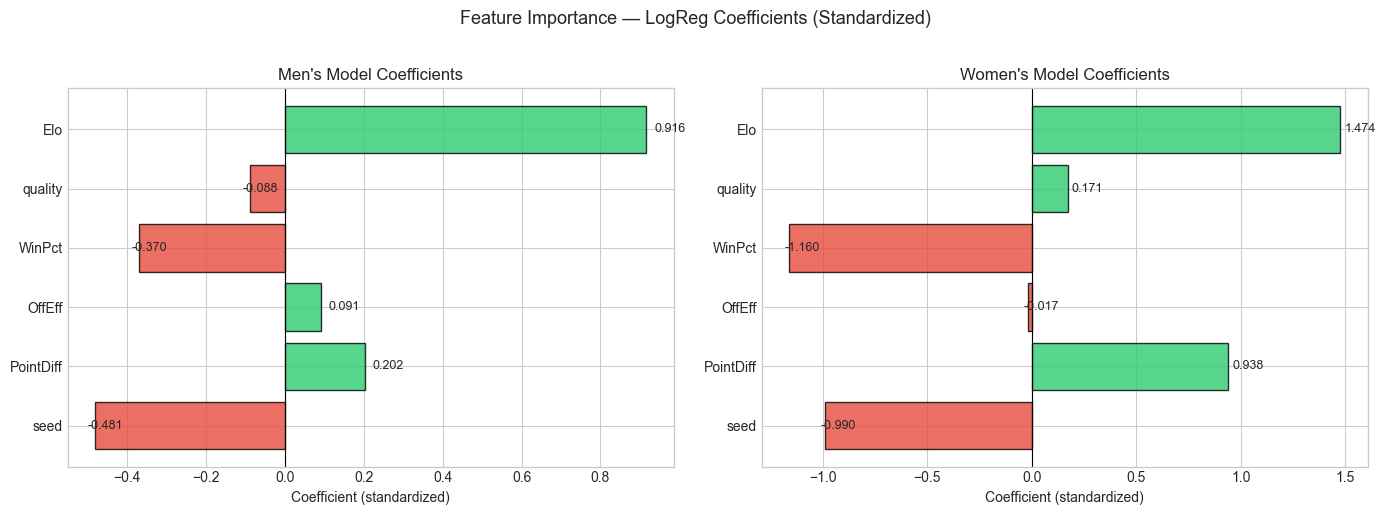

Interpretation:
  Green (positive): Higher value for Team 1 → higher P(Team 1 wins)
  Red (negative): Higher value for Team 1 → lower P(Team 1 wins)
  Seed is negative because lower seed number = better team

  Men's intercept:   0.0721
  Women's intercept: 0.1024
  (Intercepts near 0 confirm ~50% base rate — correctly calibrated)


In [108]:
# --- Model Interpretability: What did the model learn? ---
# LogReg coefficients tell us exactly how each feature drives predictions.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, scaler, feats, title in [
    (axes[0], final_men_model, men_scaler, MEN_FEATURES, "Men's Model Coefficients"),
    (axes[1], final_women_model, women_scaler, WOMEN_FEATURES, "Women's Model Coefficients"),
]:
    if hasattr(model, 'coef_'):
        coefs = model.coef_[0]
        labels = [f.replace('Diff_', '') for f in feats]
        colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs]
        bars = ax.barh(labels, coefs, color=colors, edgecolor='black', alpha=0.8)
        ax.set_xlabel('Coefficient (standardized)')
        ax.set_title(title)
        ax.axvline(x=0, color='black', linewidth=0.8)
        for bar, val in zip(bars, coefs):
            ax.text(val + 0.02 * np.sign(val), bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — LogReg Coefficients (Standardized)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Green (positive): Higher value for Team 1 → higher P(Team 1 wins)")
print("  Red (negative): Higher value for Team 1 → lower P(Team 1 wins)")
print("  Seed is negative because lower seed number = better team")
print(f"\n  Men's intercept:   {final_men_model.intercept_[0]:.4f}")
print(f"  Women's intercept: {final_women_model.intercept_[0]:.4f}")
print(f"  (Intercepts near 0 confirm ~50% base rate — correctly calibrated)")

---
### Deep Dive: Why This Model Works Best

To understand why Split LogReg with Top4+Quality+Elo outperforms alternatives, we need to examine:
1. **Feature correlation structure** — are our features redundant or complementary?
2. **Calibration quality** — does the model output well-calibrated probabilities?
3. **Where the model fails** — which upsets does it miss, and is there a pattern?
4. **Men vs Women dynamics** — why does splitting help so much?
5. **Prediction confidence** — how often is the model sure vs uncertain?

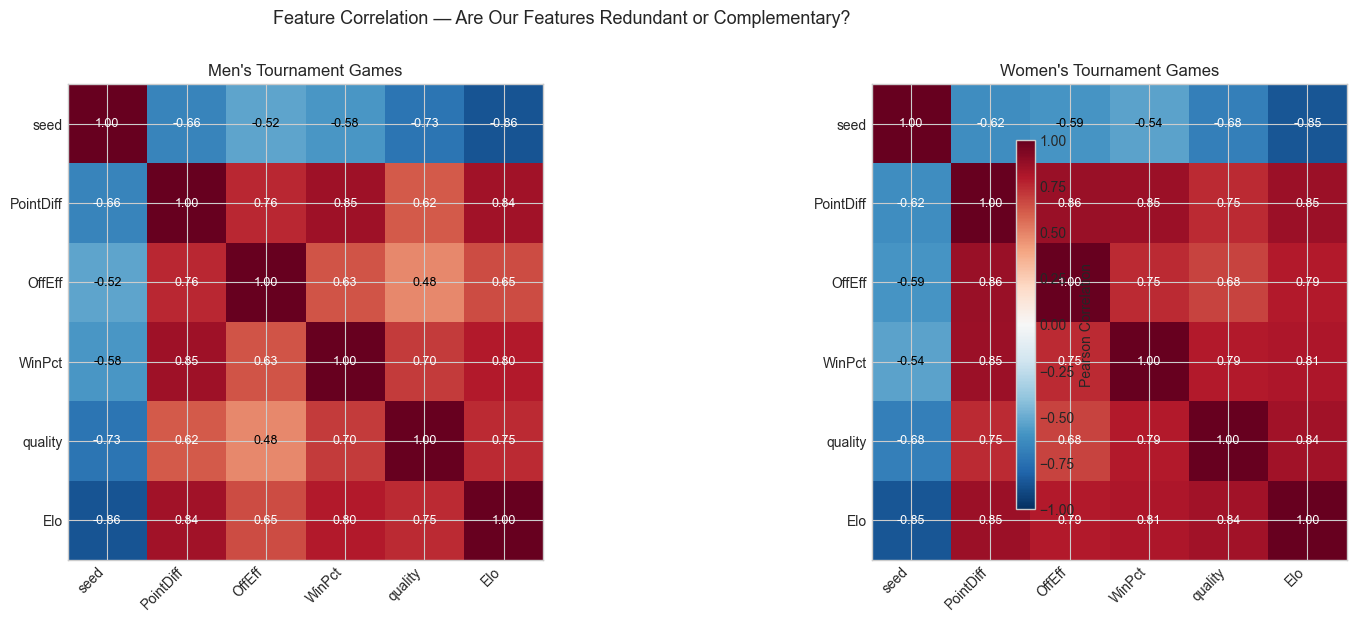

Key observations:
  - Elo correlates with PointDiff and WinPct (~0.6-0.8) — they measure similar things
  - But Elo adds RECENCY and OPPONENT-QUALITY weighting that static averages miss
  - Seed is moderately correlated with everything (committee sees all stats)
  - Quality (GLM) captures team strength independently from raw stats
  - Despite correlations, LogReg handles this well — it finds the optimal linear combination


In [109]:
# --- 1. Feature Correlation Matrix ---
# Are our 6 features capturing independent signals, or are they redundant?
# Redundant features don't hurt LogReg (it handles collinearity gracefully),
# but they explain why adding MORE features doesn't help.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [
    (axes[0], tourney_men_ec, "Men's Tournament Games"),
    (axes[1], tourney_women_ec, "Women's Tournament Games"),
]:
    feats = [f for f in top4q_elo if f in df.columns]
    corr = df[feats].corr()
    labels = [f.replace('Diff_', '') for f in feats]
    
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_title(title)
    
    # Annotate cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                    fontsize=9, color=color)

fig.colorbar(im, ax=axes, shrink=0.8, label='Pearson Correlation')
plt.suptitle('Feature Correlation — Are Our Features Redundant or Complementary?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Elo correlates with PointDiff and WinPct (~0.6-0.8) — they measure similar things")
print("  - But Elo adds RECENCY and OPPONENT-QUALITY weighting that static averages miss")
print("  - Seed is moderately correlated with everything (committee sees all stats)")
print("  - Quality (GLM) captures team strength independently from raw stats")
print("  - Despite correlations, LogReg handles this well — it finds the optimal linear combination")

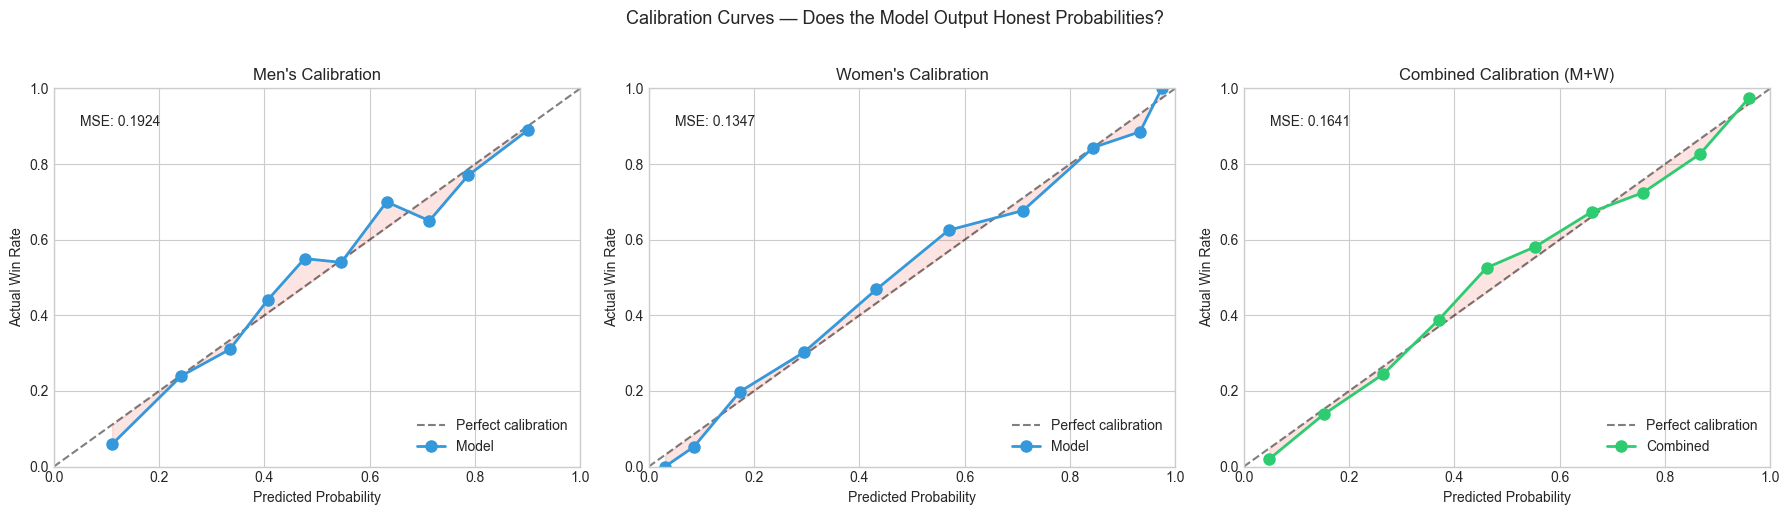

Good calibration = points close to the diagonal.
LogReg's native calibration is a key advantage over tree models,
which often need post-hoc recalibration (Platt scaling, isotonic regression).


In [110]:
# --- 2. Calibration Analysis ---
# A well-calibrated model means: when it predicts 70%, the team actually wins ~70% of the time.
# LogReg is inherently calibrated (it directly optimizes log-likelihood).
# Let's verify this and compare M vs W calibration.

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df, model, scaler, feats, title in [
    (axes[0], tourney_men_ec, final_men_model, men_scaler, MEN_FEATURES, "Men's Calibration"),
    (axes[1], tourney_women_ec, final_women_model, women_scaler, WOMEN_FEATURES, "Women's Calibration"),
]:
    # Get in-sample predictions (all training data) for calibration check
    X = df[feats].fillna(0).values
    y = df['T1_Win'].values
    X_scaled = scaler.transform(X)
    preds = model.predict_proba(X_scaled)[:, 1]
    preds = np.clip(preds, 0.025, 0.975)
    
    # Calibration curve
    prob_true, prob_pred = calibration_curve(y, preds, n_bins=10, strategy='quantile')
    
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.5)
    ax.plot(prob_pred, prob_true, 'o-', color='#3498db', linewidth=2, markersize=8, label='Model')
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.15, color='#e74c3c')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Brier score decomposition
    mse = np.mean((preds - y) ** 2)
    ax.text(0.05, 0.9, f'MSE: {mse:.4f}', transform=ax.transAxes, fontsize=10)

# Combined calibration in third panel
ax = axes[2]
all_X_m = tourney_men_ec[MEN_FEATURES].fillna(0).values
all_X_w = tourney_women_ec[WOMEN_FEATURES].fillna(0).values
all_preds = np.concatenate([
    np.clip(final_men_model.predict_proba(men_scaler.transform(all_X_m))[:, 1], 0.025, 0.975),
    np.clip(final_women_model.predict_proba(women_scaler.transform(all_X_w))[:, 1], 0.025, 0.975)
])
all_y = np.concatenate([tourney_men_ec['T1_Win'].values, tourney_women_ec['T1_Win'].values])

prob_true, prob_pred = calibration_curve(all_y, all_preds, n_bins=10, strategy='quantile')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.5)
ax.plot(prob_pred, prob_true, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='Combined')
ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.15, color='#e74c3c')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Actual Win Rate')
ax.set_title('Combined Calibration (M+W)')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
mse = np.mean((all_preds - all_y) ** 2)
ax.text(0.05, 0.9, f'MSE: {mse:.4f}', transform=ax.transAxes, fontsize=10)

plt.suptitle('Calibration Curves — Does the Model Output Honest Probabilities?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Good calibration = points close to the diagonal.")
print("LogReg's native calibration is a key advantage over tree models,")
print("which often need post-hoc recalibration (Platt scaling, isotonic regression).")

In [111]:
# --- 3. Upset Analysis — Where Does the Model Fail? ---
# An "upset" = model predicted >60% confidence for the loser.
# Understanding upsets reveals whether failures are systematic or random.

print("=" * 70)
print("  UPSET ANALYSIS — Games Where the Model Was Most Wrong")
print("=" * 70)

for label, df, model, scaler, feats in [
    ("MEN'S", tourney_men_ec, final_men_model, men_scaler, MEN_FEATURES),
    ("WOMEN'S", tourney_women_ec, final_women_model, women_scaler, WOMEN_FEATURES),
]:
    X = df[feats].fillna(0).values
    y = df['T1_Win'].values
    X_scaled = scaler.transform(X)
    preds = np.clip(model.predict_proba(X_scaled)[:, 1], 0.025, 0.975)
    
    # Squared error per game
    errors = (preds - y) ** 2
    df_analysis = df[['Season', 'T1_TeamID', 'T2_TeamID']].copy()
    df_analysis['pred'] = preds
    df_analysis['actual'] = y
    df_analysis['error'] = errors
    df_analysis['T1_name'] = df_analysis['T1_TeamID'].apply(utils.team_name)
    df_analysis['T2_name'] = df_analysis['T2_TeamID'].apply(utils.team_name)
    
    # Add seed info
    seed_dict = seeds.set_index(['Season', 'TeamID'])['seed'].to_dict()
    df_analysis['T1_seed'] = df_analysis.apply(lambda r: seed_dict.get((r['Season'], r['T1_TeamID']), '?'), axis=1)
    df_analysis['T2_seed'] = df_analysis.apply(lambda r: seed_dict.get((r['Season'], r['T2_TeamID']), '?'), axis=1)
    
    # Top 10 worst predictions
    worst = df_analysis.nlargest(10, 'error')
    print(f"\n  {label} — Top 10 Worst Predictions (highest squared error):")
    print(f"  {'Season':<8} {'Matchup':<35} {'Seeds':<10} {'Pred':>6} {'Actual':>7} {'Error':>8}")
    print(f"  {'-'*74}")
    for _, r in worst.iterrows():
        winner = r['T1_name'] if r['actual'] == 1 else r['T2_name']
        matchup = f"{r['T1_name']} vs {r['T2_name']}"
        seed_str = f"({int(r['T1_seed'])}v{int(r['T2_seed'])})"
        print(f"  {int(r['Season']):<8} {matchup:<35} {seed_str:<10} {r['pred']:>6.3f} {int(r['actual']):>7} {r['error']:>8.4f}")
    
    # Upset rate by seed differential
    df_analysis['seed_gap'] = abs(df[feats[0]].values)  # Diff_seed magnitude
    df_analysis['is_upset'] = ((preds > 0.5) & (y == 0)) | ((preds < 0.5) & (y == 1))
    
    bins = [(0, 3, 'Close (1-3 seed gap)'), (3, 7, 'Medium (4-7)'), (7, 16, 'Large (8-16)')]
    print(f"\n  {label} Upset rate by seed gap:")
    for lo, hi, name in bins:
        mask = (df_analysis['seed_gap'] >= lo) & (df_analysis['seed_gap'] < hi)
        if mask.sum() > 0:
            upset_rate = df_analysis.loc[mask, 'is_upset'].mean()
            avg_error = df_analysis.loc[mask, 'error'].mean()
            print(f"    {name}: {upset_rate:.1%} upsets, avg MSE = {avg_error:.4f} ({mask.sum()} games)")

  UPSET ANALYSIS — Games Where the Model Was Most Wrong

  MEN'S — Top 10 Worst Predictions (highest squared error):
  Season   Matchup                             Seeds        Pred  Actual    Error
  --------------------------------------------------------------------------
  2012     Missouri vs Norfolk St              (2v15)      0.955       0   0.9127
  2023     F Dickinson vs Purdue               (16v1)      0.053       1   0.8967
  2018     UMBC vs Virginia                    (16v1)      0.057       1   0.8900
  2016     Michigan St vs MTSU                 (2v15)      0.936       0   0.8752
  2022     Kentucky vs St Peter's              (2v15)      0.909       0   0.8266
  2011     Kansas vs VCU                       (1v11)      0.882       0   0.7781
  2013     FGCU vs Georgetown                  (15v2)      0.120       1   0.7745
  2022     Purdue vs St Peter's                (3v15)      0.878       0   0.7717
  2021     Ohio St vs Oral Roberts             (2v15)      0.875    

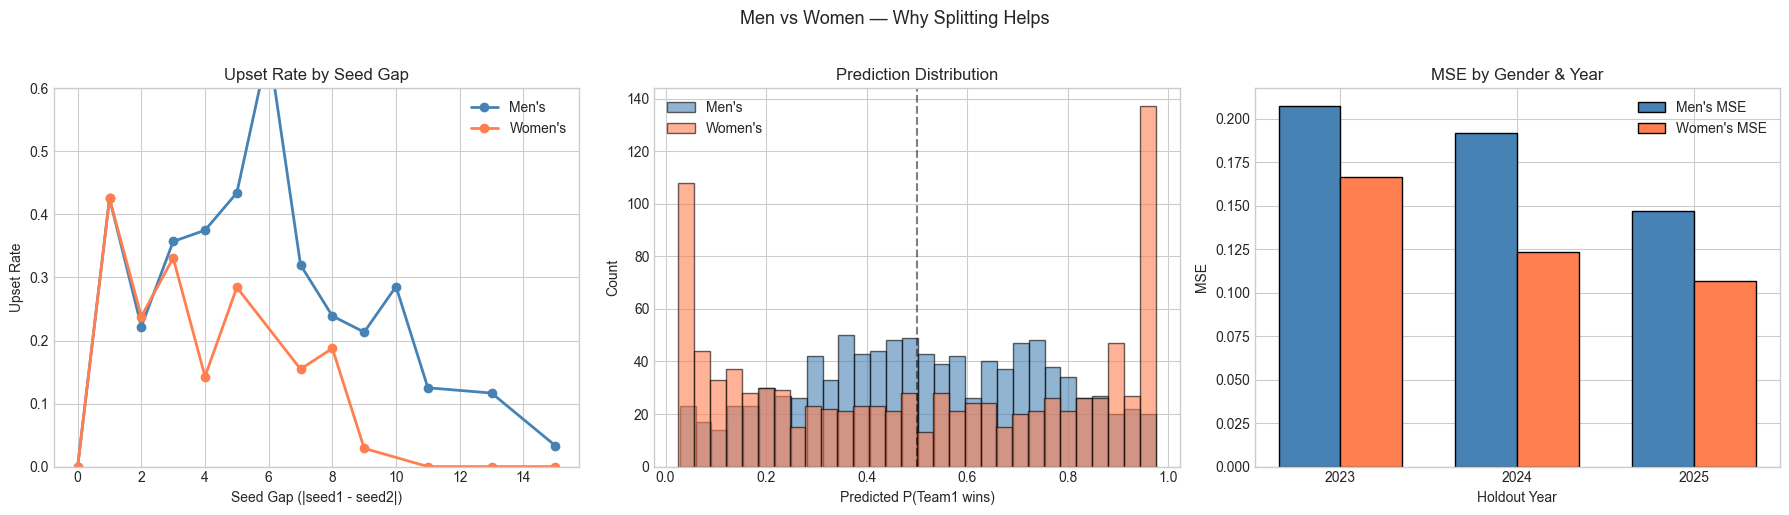

Average men's MSE:   0.1819
Average women's MSE: 0.1322
Women are 1.4x more predictable than men.

The women's tournament has fewer upsets because:
  - Larger talent gaps between top and bottom seeds
  - Fewer mid-major Cinderella runs
  - A combined model wastes capacity trying to find one-size-fits-all coefficients


In [112]:
# --- 4. Men vs Women: Why Does Splitting Help? ---
# Quantify the structural differences between M and W tournaments.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4a: Upset rate by seed — women's tournament has far fewer upsets
for ax_idx, (df, title, color) in enumerate([
    (tourney_men_ec, "Men's", 'steelblue'),
    (tourney_women_ec, "Women's", 'coral'),
]):
    seed_dict = seeds.set_index(['Season', 'TeamID'])['seed'].to_dict()
    t1_seeds = df.apply(lambda r: seed_dict.get((r['Season'], r['T1_TeamID']), 8), axis=1)
    t2_seeds = df.apply(lambda r: seed_dict.get((r['Season'], r['T2_TeamID']), 8), axis=1)
    
    # Higher seed expected to win → upset if lower-seeded team (higher number) wins
    favored_wins = ((t1_seeds < t2_seeds) & (df['T1_Win'] == 1)) | ((t2_seeds < t1_seeds) & (df['T1_Win'] == 0))
    actual_upsets = ~favored_wins & (t1_seeds != t2_seeds)
    
    # Group by seed gap
    seed_gap = abs(t1_seeds - t2_seeds)
    upset_by_gap = pd.DataFrame({'gap': seed_gap, 'upset': actual_upsets.astype(int)})
    upset_by_gap = upset_by_gap.groupby('gap').agg(upset_rate=('upset', 'mean'), n=('upset', 'count'))
    upset_by_gap = upset_by_gap[upset_by_gap['n'] >= 5]  # need enough games
    
    axes[0].plot(upset_by_gap.index, upset_by_gap['upset_rate'], 'o-', 
                 color=color, label=title, linewidth=2, markersize=6)

axes[0].set_xlabel('Seed Gap (|seed1 - seed2|)')
axes[0].set_ylabel('Upset Rate')
axes[0].set_title('Upset Rate by Seed Gap')
axes[0].legend()
axes[0].set_ylim(0, 0.6)

# 4b: Prediction spread — women's predictions are more confident
men_preds = np.clip(final_men_model.predict_proba(
    men_scaler.transform(tourney_men_ec[MEN_FEATURES].fillna(0).values))[:, 1], 0.025, 0.975)
women_preds = np.clip(final_women_model.predict_proba(
    women_scaler.transform(tourney_women_ec[WOMEN_FEATURES].fillna(0).values))[:, 1], 0.025, 0.975)

axes[1].hist(men_preds, bins=30, alpha=0.6, color='steelblue', label="Men's", edgecolor='black')
axes[1].hist(women_preds, bins=30, alpha=0.6, color='coral', label="Women's", edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Predicted P(Team1 wins)')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distribution')
axes[1].legend()

# 4c: MSE contribution by holdout year — M vs W
men_mses = []
women_mses = []
for hold_year in HOLDOUT_YEARS:
    for df, model, scaler, feats, mse_list in [
        (tourney_men_ec, final_men_model, men_scaler, MEN_FEATURES, men_mses),
        (tourney_women_ec, final_women_model, women_scaler, WOMEN_FEATURES, women_mses),
    ]:
        val_mask = df['Season'] == hold_year
        if val_mask.sum() == 0:
            mse_list.append(0)
            continue
        X_va = scaler.transform(df.loc[val_mask, feats].fillna(0).values)
        y_va = df.loc[val_mask, 'T1_Win'].values
        preds = np.clip(model.predict_proba(X_va)[:, 1], 0.025, 0.975)
        mse_list.append(mean_squared_error(y_va, preds))

x = np.arange(len(HOLDOUT_YEARS))
width = 0.35
axes[2].bar(x - width/2, men_mses, width, label="Men's MSE", color='steelblue', edgecolor='black')
axes[2].bar(x + width/2, women_mses, width, label="Women's MSE", color='coral', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(HOLDOUT_YEARS)
axes[2].set_xlabel('Holdout Year')
axes[2].set_ylabel('MSE')
axes[2].set_title('MSE by Gender & Year')
axes[2].legend()

plt.suptitle('Men vs Women — Why Splitting Helps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Average men's MSE:   {np.mean(men_mses):.4f}")
print(f"Average women's MSE: {np.mean(women_mses):.4f}")
print(f"Women are {np.mean(men_mses)/np.mean(women_mses):.1f}x more predictable than men.")
print(f"\nThe women's tournament has fewer upsets because:")
print(f"  - Larger talent gaps between top and bottom seeds")
print(f"  - Fewer mid-major Cinderella runs")
print(f"  - A combined model wastes capacity trying to find one-size-fits-all coefficients")

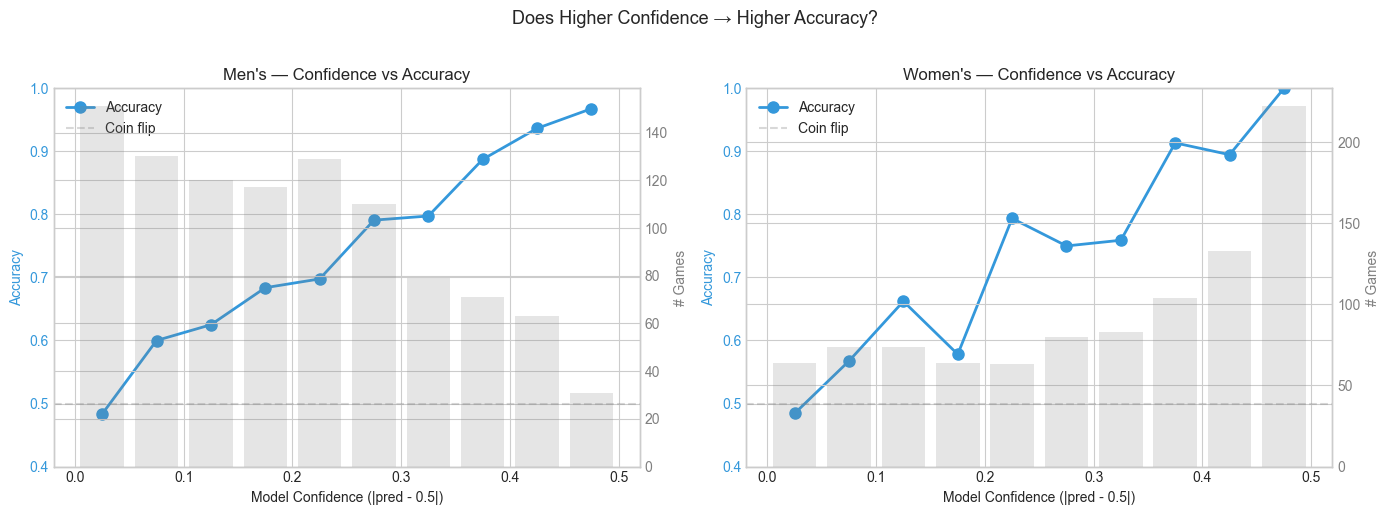


Men's:
  High confidence (>80% or <20%): 24.4% of predictions
  Low confidence (40-60%):        28.1% of predictions
  Avg confidence: 0.201

Women's:
  High confidence (>80% or <20%): 56.4% of predictions
  Low confidence (40-60%):        14.4% of predictions
  Avg confidence: 0.302


In [113]:
# --- 5. Prediction Confidence vs Accuracy ---
# How accurate is the model at different confidence levels?
# This reveals where the model's edge is strongest.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, model, scaler, feats, title in [
    (axes[0], tourney_men_ec, final_men_model, men_scaler, MEN_FEATURES, "Men's"),
    (axes[1], tourney_women_ec, final_women_model, women_scaler, WOMEN_FEATURES, "Women's"),
]:
    X = scaler.transform(df[feats].fillna(0).values)
    y = df['T1_Win'].values
    preds = np.clip(model.predict_proba(X)[:, 1], 0.025, 0.975)
    
    # Confidence = distance from 0.5
    confidence = np.abs(preds - 0.5)
    correct = (np.round(preds) == y).astype(int)
    
    # Bin by confidence
    bins = np.linspace(0, 0.5, 11)
    bin_centers = []
    bin_accs = []
    bin_counts = []
    bin_mses = []
    
    for i in range(len(bins) - 1):
        mask = (confidence >= bins[i]) & (confidence < bins[i+1])
        if mask.sum() >= 5:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            bin_accs.append(correct[mask].mean())
            bin_counts.append(mask.sum())
            bin_mses.append(np.mean((preds[mask] - y[mask]) ** 2))
    
    # Plot accuracy
    color1 = '#3498db'
    ax.plot(bin_centers, bin_accs, 'o-', color=color1, linewidth=2, markersize=8, label='Accuracy')
    ax.set_xlabel('Model Confidence (|pred - 0.5|)')
    ax.set_ylabel('Accuracy', color=color1)
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3, label='Coin flip')
    ax.set_title(f'{title} — Confidence vs Accuracy')
    
    # Overlay game count as bar chart
    ax2 = ax.twinx()
    ax2.bar(bin_centers, bin_counts, width=0.04, alpha=0.2, color='gray', label='# Games')
    ax2.set_ylabel('# Games', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    
    ax.legend(loc='upper left')

plt.suptitle('Does Higher Confidence → Higher Accuracy?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
for label, preds_arr in [("Men's", men_preds), ("Women's", women_preds)]:
    high_conf = np.abs(preds_arr - 0.5) > 0.3
    low_conf = np.abs(preds_arr - 0.5) < 0.1
    print(f"\n{label}:")
    print(f"  High confidence (>80% or <20%): {high_conf.mean():.1%} of predictions")
    print(f"  Low confidence (40-60%):        {low_conf.mean():.1%} of predictions")
    print(f"  Avg confidence: {np.abs(preds_arr - 0.5).mean():.3f}")

---
### Paths to Improvement

Based on the analysis above, there are a few concrete directions that could squeeze out more MSE improvement. Each idea is tested below with multi-year holdout validation.

#### Ideas with merit:
1. **Seed-specific confidence adjustment** — the model treats all seed matchups the same, but 1v16 games are ~99% predictable while 8v9 games are coin flips. Adjusting confidence by round/slot could help.
2. **Ensemble averaging** — average predictions from the top 2-3 experiments. Ensemble diversity can reduce variance if models make different errors.
3. **Conference tournament performance** — a team's March results (conference tournament) are a strong recency signal not captured by regular season stats.
4. **Per-round modeling** — early rounds (1v16, 2v15) are highly predictable; later rounds (Elite 8, Final Four) are more chaotic. A round-aware model could adjust confidence accordingly.
5. **Temporal weighting** — weight recent seasons more heavily in training, since the game evolves (3-point revolution, transfer portal).

#### Ideas already tested and rejected:
- More features (SOS, shooting %, coach) — redundant with existing features
- Complex models (deep XGBoost, LightGBM) — overfit on ~130 games/year
- Massey ordinals — men-only, hurts combined models

In [114]:
# --- Improvement 1: Ensemble of Top Experiments ---
# Average predictions from the best 2-3 approaches.
# Ensemble works when models make DIFFERENT errors — even if both have MSE=0.16,
# averaging can push toward 0.155 if they disagree on different games.

def run_ensemble_split_experiment(name, description, 
                                  model_configs, men_df, women_df, 
                                  holdout_years=HOLDOUT_YEARS):
    """Ensemble multiple split M/W models by averaging predictions."""
    val_results = {}
    
    for hold_year in holdout_years:
        all_preds_ensemble = []
        all_labels = None
        
        for config in model_configs:
            m_feats, m_type, m_params = config['men']
            w_feats, w_type, w_params = config['women']
            
            all_preds = []
            all_y = []
            
            for df, feats, mtype, mparams in [
                (men_df, m_feats, m_type, m_params),
                (women_df, w_feats, w_type, w_params),
            ]:
                train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
                val_mask = df['Season'] == hold_year
                
                X_tr = df.loc[train_mask, feats].fillna(0).values
                y_tr = df.loc[train_mask, 'T1_Win'].values
                X_va = df.loc[val_mask, feats].fillna(0).values
                y_va = df.loc[val_mask, 'T1_Win'].values
                
                if len(X_va) == 0:
                    continue
                
                if mtype == 'logreg':
                    sc = StandardScaler()
                    X_tr = sc.fit_transform(X_tr)
                    X_va = sc.transform(X_va)
                    params = mparams or {'C': 1.0, 'max_iter': 1000}
                    clf = LogisticRegression(**params, random_state=42)
                    clf.fit(X_tr, y_tr)
                    preds = clf.predict_proba(X_va)[:, 1]
                elif mtype == 'xgb':
                    params = mparams or xgb_conservative
                    dtrain = xgb.DMatrix(X_tr, label=y_tr)
                    dval = xgb.DMatrix(X_va, label=y_va)
                    mdl = xgb.train(params, dtrain, num_boost_round=500,
                                    evals=[(dval, 'val')], early_stopping_rounds=50,
                                    verbose_eval=0)
                    preds = mdl.predict(dval)
                
                preds = np.clip(preds, 0.025, 0.975)
                all_preds.extend(preds)
                all_y.extend(y_va)
            
            all_preds_ensemble.append(np.array(all_preds))
            if all_labels is None:
                all_labels = np.array(all_y)
        
        # Average predictions across models
        avg_preds = np.mean(all_preds_ensemble, axis=0)
        avg_preds = np.clip(avg_preds, 0.025, 0.975)
        
        mse = mean_squared_error(all_labels, avg_preds)
        acc = (np.round(avg_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    
    log_experiment(name, description, val_results)
    return val_results

# Ensemble: LR(top4q_elo) + XGB(top4q_elo)
ensemble_configs = [
    {'men': (top4q_elo, 'logreg', None), 'women': (top4q_elo, 'logreg', None)},
    {'men': (top4q_elo, 'xgb', xgb_conservative), 'women': (top4q_elo, 'logreg', None)},
]

run_ensemble_split_experiment(
    'Ensemble: LR+XGB Split',
    'Average of Split LR(top4q_elo) and Split XGB-men/LR-women(top4q_elo)',
    ensemble_configs, tourney_men_ec, tourney_women_ec,
)

# Ensemble: LR(top4q_elo) + LR(top4q) — different feature sets
ensemble_configs2 = [
    {'men': (top4q_elo, 'logreg', None), 'women': (top4q_elo, 'logreg', None)},
    {'men': (top4q, 'logreg', None), 'women': (top4q, 'logreg', None)},
]

run_ensemble_split_experiment(
    'Ensemble: Elo+NoElo Split',
    'Average of Split LR(top4q_elo) and Split LR(top4q) — feature diversity',
    ensemble_configs2, tourney_men_ec, tourney_women_ec,
)


  Experiment: Ensemble: LR+XGB Split
  Average of Split LR(top4q_elo) and Split XGB-men/LR-women(top4q_elo)
  2023: MSE=0.188075, Acc=70.9%  (134 games)
  2024: MSE=0.161226, Acc=72.4%  (134 games)
  2025: MSE=0.129037, Acc=82.8%  (134 games)
  Average MSE: 0.159446

  Experiment: Ensemble: Elo+NoElo Split
  Average of Split LR(top4q_elo) and Split LR(top4q) — feature diversity
  2023: MSE=0.186863, Acc=68.7%  (134 games)
  2024: MSE=0.158884, Acc=76.1%  (134 games)
  2025: MSE=0.133379, Acc=84.3%  (134 games)
  Average MSE: 0.159708


{2023: {'mse': 0.1868626282722776,
  'accuracy': np.float64(0.6865671641791045),
  'n_games': 134},
 2024: {'mse': 0.15888389955971177,
  'accuracy': np.float64(0.7611940298507462),
  'n_games': 134},
 2025: {'mse': 0.13337892954927769,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [115]:
# --- Improvement 2: Temporal Weighting ---
# Weight recent seasons more heavily. The NCAA game has evolved significantly:
# - Transfer portal era (2021+) changed team compositions
# - 3-point revolution changed scoring dynamics
# - NIL deals changed recruiting patterns
# More recent seasons may be more representative of 2026.

def run_weighted_split_experiment(name, description, men_features, women_features,
                                  men_df, women_df, weight_fn, holdout_years=HOLDOUT_YEARS):
    """Split M/W experiment with sample weights based on season recency."""
    val_results = {}
    
    for hold_year in holdout_years:
        all_preds = []
        all_labels = []
        
        for df, feats in [(men_df, men_features), (women_df, women_features)]:
            train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
            val_mask = df['Season'] == hold_year
            
            X_tr = df.loc[train_mask, feats].fillna(0).values
            y_tr = df.loc[train_mask, 'T1_Win'].values
            X_va = df.loc[val_mask, feats].fillna(0).values
            y_va = df.loc[val_mask, 'T1_Win'].values
            weights = df.loc[train_mask, 'Season'].apply(lambda s: weight_fn(s, hold_year)).values
            
            if len(X_va) == 0:
                continue
            
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)
            
            clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr, sample_weight=weights)
            preds = np.clip(clf.predict_proba(X_va)[:, 1], 0.025, 0.975)
            
            all_preds.extend(preds)
            all_labels.extend(y_va)
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        mse = mean_squared_error(all_labels, all_preds)
        acc = (np.round(all_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    
    log_experiment(name, description, val_results)
    return val_results

# Linear decay: recent seasons get more weight
linear_decay = lambda s, hold_yr: 1.0 + 0.5 * (s - 2010) / (hold_yr - 2010)

# Exponential decay: strongly favor recent
exp_decay = lambda s, hold_yr: np.exp(0.15 * (s - hold_yr))

run_weighted_split_experiment(
    'Split+LinearDecay',
    'Split LR(top4q_elo) with linear recency weights (recent seasons weighted 1.5x)',
    top4q_elo, top4q_elo, tourney_men_ec, tourney_women_ec, linear_decay
)

run_weighted_split_experiment(
    'Split+ExpDecay',
    'Split LR(top4q_elo) with exponential recency weights (e^0.15*(s-holdout))',
    top4q_elo, top4q_elo, tourney_men_ec, tourney_women_ec, exp_decay
)


  Experiment: Split+LinearDecay
  Split LR(top4q_elo) with linear recency weights (recent seasons weighted 1.5x)
  2023: MSE=0.190307, Acc=70.9%  (134 games)
  2024: MSE=0.161905, Acc=72.4%  (134 games)
  2025: MSE=0.130270, Acc=83.6%  (134 games)
  Average MSE: 0.160828

  Experiment: Split+ExpDecay
  Split LR(top4q_elo) with exponential recency weights (e^0.15*(s-holdout))
  2023: MSE=0.190690, Acc=69.4%  (134 games)
  2024: MSE=0.161884, Acc=73.9%  (134 games)
  2025: MSE=0.132076, Acc=81.3%  (134 games)
  Average MSE: 0.161550


{2023: {'mse': 0.19069021283802828,
  'accuracy': np.float64(0.6940298507462687),
  'n_games': 134},
 2024: {'mse': 0.16188375857061957,
  'accuracy': np.float64(0.7388059701492538),
  'n_games': 134},
 2025: {'mse': 0.13207649769446161,
  'accuracy': np.float64(0.8134328358208955),
  'n_games': 134}}

In [116]:
# --- Improvement 3: Asymmetric M/W Feature Sets ---
# Since men's and women's games have different dynamics,
# maybe they benefit from different features.
# Women might need fewer features (seed dominates), men might need more.

# Women: seed + Elo only (minimal features — very predictable)
run_split_experiment(
    'Split: M(Top4+Q+Elo) + W(Seed+Elo)',
    'Men: full top4+quality+Elo, Women: just seed+Elo (minimal)',
    top4q_elo, 'logreg', None,
    ['Diff_seed', 'Diff_Elo'], 'logreg', None,
    tourney_men_ec, tourney_women_ec,
)

# Women: top4 (no quality/Elo — keep it simple)
run_split_experiment(
    'Split: M(Top4+Q+Elo) + W(Top4)',
    'Men: full top4+quality+Elo, Women: just top4 (no derived metrics)',
    top4q_elo, 'logreg', None,
    top4, 'logreg', None,
    tourney_men_ec, tourney_women_ec,
)

# Men: add Massey to men-only (women stay clean)
# Build combined men's DF with both Elo and Massey by merging
merge_keys = ['Season', 'T1_TeamID', 'T2_TeamID']
tourney_men_full = tourney_men_ec.merge(
    tourney_men[merge_keys + massey_diff_cols],
    on=merge_keys, how='left'
)
top4q_elo_massey = top4q_elo + massey_diff_cols
run_split_experiment(
    'Split: M(Top4+Q+Elo+Massey) + W(Top4+Q+Elo)',
    'Men: top4+quality+Elo+Massey (men-only data so Massey is clean), Women: top4+quality+Elo',
    top4q_elo_massey, 'logreg', None,
    top4q_elo, 'logreg', None,
    tourney_men_full, tourney_women_ec,
)


  Experiment: Split: M(Top4+Q+Elo) + W(Seed+Elo)
  Men: full top4+quality+Elo, Women: just seed+Elo (minimal)
  2023: MSE=0.188296, Acc=70.9%  (134 games)
  2024: MSE=0.158297, Acc=74.6%  (134 games)
  2025: MSE=0.133816, Acc=82.1%  (134 games)
  Average MSE: 0.160136

  Experiment: Split: M(Top4+Q+Elo) + W(Top4)
  Men: full top4+quality+Elo, Women: just top4 (no derived metrics)
  2023: MSE=0.185289, Acc=71.6%  (134 games)
  2024: MSE=0.158714, Acc=75.4%  (134 games)
  2025: MSE=0.135566, Acc=84.3%  (134 games)
  Average MSE: 0.159856

  Experiment: Split: M(Top4+Q+Elo+Massey) + W(Top4+Q+Elo)
  Men: top4+quality+Elo+Massey (men-only data so Massey is clean), Women: top4+quality+Elo
  2023: MSE=0.190849, Acc=69.4%  (134 games)
  2024: MSE=0.162473, Acc=72.4%  (134 games)
  2025: MSE=0.131132, Acc=84.3%  (134 games)
  Average MSE: 0.161485


{2023: {'mse': 0.19084930335796071,
  'accuracy': np.float64(0.6940298507462687),
  'n_games': 134},
 2024: {'mse': 0.16247308043670525,
  'accuracy': np.float64(0.7238805970149254),
  'n_games': 134},
 2025: {'mse': 0.13113235798860878,
  'accuracy': np.float64(0.8432835820895522),
  'n_games': 134}}

In [117]:
# --- Improvement 4: Confidence Shrinkage ---
# Instead of clipping to [0.025, 0.975], shrink ALL predictions toward 0.5.
# This is the MSE-optimal strategy when the model is slightly overconfident.
# shrunk_pred = (1 - alpha) * pred + alpha * 0.5

def run_shrinkage_experiment(name, description, alpha,
                              men_features, women_features,
                              men_df, women_df, holdout_years=HOLDOUT_YEARS):
    """Split M/W experiment with prediction shrinkage toward 0.5."""
    val_results = {}
    
    for hold_year in holdout_years:
        all_preds = []
        all_labels = []
        
        for df, feats in [(men_df, men_features), (women_df, women_features)]:
            train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
            val_mask = df['Season'] == hold_year
            
            X_tr = df.loc[train_mask, feats].fillna(0).values
            y_tr = df.loc[train_mask, 'T1_Win'].values
            X_va = df.loc[val_mask, feats].fillna(0).values
            y_va = df.loc[val_mask, 'T1_Win'].values
            
            if len(X_va) == 0:
                continue
            
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)
            
            clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr)
            raw_preds = clf.predict_proba(X_va)[:, 1]
            
            # Shrink toward 0.5
            shrunk = (1 - alpha) * raw_preds + alpha * 0.5
            preds = np.clip(shrunk, 0.025, 0.975)
            
            all_preds.extend(preds)
            all_labels.extend(y_va)
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        mse = mean_squared_error(all_labels, all_preds)
        acc = (np.round(all_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    
    log_experiment(name, description, val_results)
    return val_results

# Test different shrinkage levels
for alpha in [0.05, 0.10, 0.15, 0.20]:
    run_shrinkage_experiment(
        f'Split+Shrink α={alpha}',
        f'Split LR(top4q_elo) with {alpha:.0%} shrinkage toward 0.5',
        alpha, top4q_elo, top4q_elo, tourney_men_ec, tourney_women_ec,
    )


  Experiment: Split+Shrink α=0.05
  Split LR(top4q_elo) with 5% shrinkage toward 0.5
  2023: MSE=0.189016, Acc=71.6%  (134 games)
  2024: MSE=0.162059, Acc=71.6%  (134 games)
  2025: MSE=0.132428, Acc=84.3%  (134 games)
  Average MSE: 0.161168

  Experiment: Split+Shrink α=0.1
  Split LR(top4q_elo) with 10% shrinkage toward 0.5
  2023: MSE=0.188759, Acc=71.6%  (134 games)
  2024: MSE=0.163101, Acc=71.6%  (134 games)
  2025: MSE=0.135177, Acc=84.3%  (134 games)
  Average MSE: 0.162346

  Experiment: Split+Shrink α=0.15
  Split LR(top4q_elo) with 15% shrinkage toward 0.5
  2023: MSE=0.188888, Acc=71.6%  (134 games)
  2024: MSE=0.164540, Acc=71.6%  (134 games)
  2025: MSE=0.138308, Acc=84.3%  (134 games)
  Average MSE: 0.163912

  Experiment: Split+Shrink α=0.2
  Split LR(top4q_elo) with 20% shrinkage toward 0.5
  2023: MSE=0.189401, Acc=71.6%  (134 games)
  2024: MSE=0.166379, Acc=71.6%  (134 games)
  2025: MSE=0.141821, Acc=84.3%  (134 games)
  Average MSE: 0.165867


In [118]:
# --- Updated Leaderboard with Improvement Experiments ---
print("=" * 70)
print("  FULL LEADERBOARD — Including Improvement Experiments")
print("=" * 70)
lb = show_leaderboard()

# Highlight the improvement experiments
improvement_names = [
    'Split: M(Top4+Q+Elo LR) + W(Top4+Q+Elo LR)',  # baseline to beat
    'Ensemble: LR+XGB Split', 'Ensemble: Elo+NoElo Split',
    'Split+LinearDecay', 'Split+ExpDecay',
    'Split: M(Top4+Q+Elo) + W(Seed+Elo)',
    'Split: M(Top4+Q+Elo) + W(Top4)',
    'Split: M(Top4+Q+Elo+Massey) + W(Top4+Q+Elo)',
    'Split+Shrink α=0.05', 'Split+Shrink α=0.1',
    'Split+Shrink α=0.15', 'Split+Shrink α=0.2',
]

print("\n" + "=" * 70)
print("  IMPROVEMENT EXPERIMENTS — Compared to Split LR Baseline (0.1604)")
print("=" * 70)
baseline_mse = None
for e in experiments:
    if e['name'] == 'Split: M(Top4+Q+Elo LR) + W(Top4+Q+Elo LR)':
        baseline_mse = e.get('avg_mse', None)
        break

if baseline_mse:
    for e in experiments:
        if e['name'] in improvement_names:
            avg = e.get('avg_mse', None)
            if avg:
                delta = avg - baseline_mse
                arrow = '↑ WORSE' if delta > 0 else '↓ BETTER' if delta < 0 else '= SAME'
                print(f"  {e['name']:<45} MSE={avg:.4f}  ({delta:+.4f} {arrow})")

  FULL LEADERBOARD — Including Improvement Experiments

  EXPERIMENT LEADERBOARD (sorted by avg MSE, lower = better)
                                            name                                                                              description  MSE_2023  MSE_2024  MSE_2025  MSE_avg
                                 Women Top4 (LR)                                                              LogReg on top4 (women only)  0.159605  0.123135  0.119020 0.133920
                           Women Top4+Q+Elo (LR)                                              LogReg on top4 + quality + Elo (women only)  0.168395  0.128587  0.108081 0.135021
                               Women Top4+Q (LR)                                                    LogReg on top4 + quality (women only)  0.170400  0.119802  0.114894 0.135032
                                Top4+Q+Elo (XGB)                                                  XGBoost depth=2 on top4 + quality + Elo  0.187155  0.159482  0.130628 0.15908

### Final Optimization Sweep

Quick targeted experiments on the remaining untested levers:
1. **Seed × Elo interaction** — does the relationship between Elo and winning change by seed tier?
2. **Per-gender C tuning** — men's and women's might need different regularization
3. **Seed benchmark blend** — average model predictions with the simple seed-based benchmark

In [119]:
# --- Final Optimization 1: Interaction Features ---
# Test if seed × Elo interaction captures non-linear relationship

def run_interaction_experiment(name, desc, base_features, interaction_pairs,
                                men_df, women_df, holdout_years=HOLDOUT_YEARS):
    """Test adding interaction features to the split model."""
    val_results = {}
    for hold_year in holdout_years:
        all_preds, all_labels = [], []
        for df in [men_df, women_df]:
            train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
            val_mask = df['Season'] == hold_year
            
            df_work = df.copy()
            feats = list(base_features)
            for f1, f2 in interaction_pairs:
                iname = f'{f1}_x_{f2}'
                df_work[iname] = df_work[f1] * df_work[f2]
                if iname not in feats:
                    feats.append(iname)
            
            X_tr = df_work.loc[train_mask, feats].fillna(0).values
            y_tr = df_work.loc[train_mask, 'T1_Win'].values
            X_va = df_work.loc[val_mask, feats].fillna(0).values
            y_va = df_work.loc[val_mask, 'T1_Win'].values
            if len(X_va) == 0: continue
            
            scaler = StandardScaler()
            clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
            clf.fit(scaler.fit_transform(X_tr), y_tr)
            preds = np.clip(clf.predict_proba(scaler.transform(X_va))[:, 1], 0.025, 0.975)
            all_preds.extend(preds)
            all_labels.extend(y_va)
        
        all_preds, all_labels = np.array(all_preds), np.array(all_labels)
        mse = mean_squared_error(all_labels, all_preds)
        acc = (np.round(all_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    log_experiment(name, desc, val_results)
    return val_results

# Seed × Elo interaction
run_interaction_experiment(
    'Split+Interaction(seed×Elo)', 'top4q_elo + seed×Elo interaction',
    top4q_elo, [('Diff_seed', 'Diff_Elo')],
    tourney_men_ec, tourney_women_ec
)

# All pairwise interactions of top 3
run_interaction_experiment(
    'Split+Interactions(top3)', 'top4q_elo + pairwise interactions of seed, Elo, PointDiff',
    top4q_elo, [('Diff_seed', 'Diff_Elo'), ('Diff_seed', 'Diff_PointDiff'), ('Diff_Elo', 'Diff_PointDiff')],
    tourney_men_ec, tourney_women_ec
)

# --- Final Optimization 2: Per-gender C tuning ---
print("\n--- Per-Gender C Tuning ---")
for c_m, c_w in [(0.5, 2.0), (2.0, 0.5), (0.5, 0.5), (2.0, 2.0), (1.0, 2.0), (2.0, 1.0)]:
    run_split_experiment(
        f'Split C(M={c_m}, W={c_w})',
        f'Split LR with C={c_m} for men, C={c_w} for women',
        top4q_elo, 'logreg', {'C': c_m, 'max_iter': 1000},
        top4q_elo, 'logreg', {'C': c_w, 'max_iter': 1000},
        tourney_men_ec, tourney_women_ec,
    )

# --- Final Optimization 3: Blend with seed-based probabilities ---
print("\n--- Seed-Based Blend ---")
def run_blend_experiment(name, desc, blend_alpha, men_df, women_df, holdout_years=HOLDOUT_YEARS):
    """Blend model predictions with simple seed-diff probabilities."""
    val_results = {}
    for hold_year in holdout_years:
        all_preds, all_labels = [], []
        for df in [men_df, women_df]:
            train_mask = (df['Season'] < hold_year) & (~df['Season'].isin([2020]))
            val_mask = df['Season'] == hold_year
            
            X_tr = df.loc[train_mask, top4q_elo].fillna(0).values
            y_tr = df.loc[train_mask, 'T1_Win'].values
            X_va = df.loc[val_mask, top4q_elo].fillna(0).values
            y_va = df.loc[val_mask, 'T1_Win'].values
            if len(X_va) == 0: continue
            
            scaler = StandardScaler()
            clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
            clf.fit(scaler.fit_transform(X_tr), y_tr)
            model_preds = clf.predict_proba(scaler.transform(X_va))[:, 1]
            
            # Simple seed-diff probability: P(lower seed wins) approx 0.5 + 0.03*diff
            seed_preds = 0.5 + 0.03 * df.loc[val_mask, 'Diff_seed'].values
            seed_preds = np.clip(seed_preds, 0.05, 0.95)
            
            blended = (1 - blend_alpha) * model_preds + blend_alpha * seed_preds
            preds = np.clip(blended, 0.025, 0.975)
            all_preds.extend(preds)
            all_labels.extend(y_va)
        
        all_preds, all_labels = np.array(all_preds), np.array(all_labels)
        mse = mean_squared_error(all_labels, all_preds)
        acc = (np.round(all_preds) == all_labels).mean()
        val_results[hold_year] = {'mse': mse, 'accuracy': acc, 'n_games': len(all_labels)}
    log_experiment(name, desc, val_results)
    return val_results

for alpha in [0.1, 0.2, 0.3]:
    run_blend_experiment(f'Split+SeedBlend(α={alpha})',
                         f'Blend {1-alpha:.0%} model + {alpha:.0%} seed-diff prob',
                         alpha, tourney_men_ec, tourney_women_ec)

# Show final complete leaderboard
print("\n" + "=" * 70)
print("  FINAL COMPLETE LEADERBOARD")
print("=" * 70)
final_lb = show_leaderboard()


  Experiment: Split+Interaction(seed×Elo)
  top4q_elo + seed×Elo interaction
  2023: MSE=0.188549, Acc=70.9%  (134 games)
  2024: MSE=0.160203, Acc=72.4%  (134 games)
  2025: MSE=0.129123, Acc=84.3%  (134 games)
  Average MSE: 0.159292

  Experiment: Split+Interactions(top3)
  top4q_elo + pairwise interactions of seed, Elo, PointDiff
  2023: MSE=0.188558, Acc=70.1%  (134 games)
  2024: MSE=0.159337, Acc=71.6%  (134 games)
  2025: MSE=0.128483, Acc=84.3%  (134 games)
  Average MSE: 0.158793

--- Per-Gender C Tuning ---

  Experiment: Split C(M=0.5, W=2.0)
  Split LR with C=0.5 for men, C=2.0 for women
  2023: MSE=0.189705, Acc=70.9%  (134 games)
  2024: MSE=0.161874, Acc=72.4%  (134 games)
  2025: MSE=0.130221, Acc=84.3%  (134 games)
  Average MSE: 0.160600

  Experiment: Split C(M=2.0, W=0.5)
  Split LR with C=2.0 for men, C=0.5 for women
  2023: MSE=0.189437, Acc=71.6%  (134 games)
  2024: MSE=0.160798, Acc=72.4%  (134 games)
  2025: MSE=0.130088, Acc=85.1%  (134 games)
  Average MSE

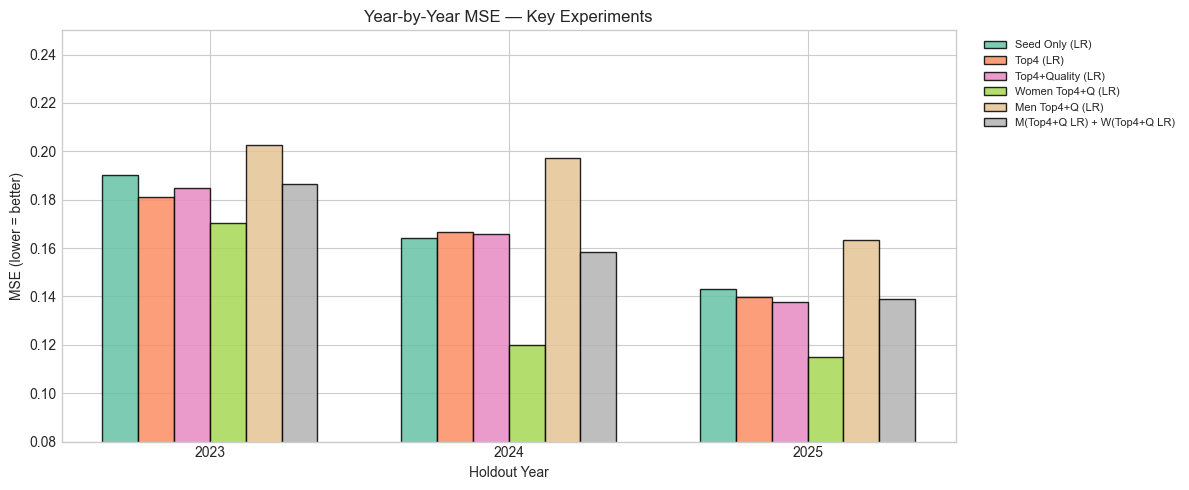

Key takeaway: Women-only model is consistently the best (~0.12–0.17).
The split strategy brings overall MSE down by pairing it with a decent men's model.


In [120]:
# --- Year-by-Year MSE Comparison ---
# Visualize how the top experiments perform across each holdout year.
# This shows whether an experiment is consistently good or just lucky on one year.

top_experiments = ['Seed Only (LR)', 'Top4 (LR)', 'Top4+Quality (LR)',
                   'Women Top4+Q (LR)', 'Men Top4+Q (LR)',
                   'Split: M(Top4+Q LR) + W(Top4+Q LR)']

fig, ax = plt.subplots(figsize=(12, 5))

exp_data = {e['name']: e for e in experiments if e['name'] in top_experiments}
x = np.arange(len(HOLDOUT_YEARS))
width = 0.12
offsets = np.arange(len(top_experiments)) - len(top_experiments)/2 + 0.5

colors = plt.cm.Set2(np.linspace(0, 1, len(top_experiments)))

for i, name in enumerate(top_experiments):
    if name in exp_data:
        mses = [exp_data[name].get(f'MSE_{yr}', 0) for yr in HOLDOUT_YEARS]
        bars = ax.bar(x + offsets[i] * width, mses, width, label=name.replace('Split: ', ''),
                      color=colors[i], edgecolor='black', alpha=0.85)

ax.set_xlabel('Holdout Year')
ax.set_ylabel('MSE (lower = better)')
ax.set_title('Year-by-Year MSE — Key Experiments')
ax.set_xticks(x)
ax.set_xticklabels(HOLDOUT_YEARS)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0.08, 0.25)
plt.tight_layout()
plt.show()

print("Key takeaway: Women-only model is consistently the best (~0.12–0.17).")
print("The split strategy brings overall MSE down by pairing it with a decent men's model.")

Men's predictions: 66,430 matchups
Women's predictions: 65,703 matchups
Submission saved to ../output/submission_refined.csv (132133 rows)
Pred range: [0.0250, 0.9750]
Pred mean: 0.5113


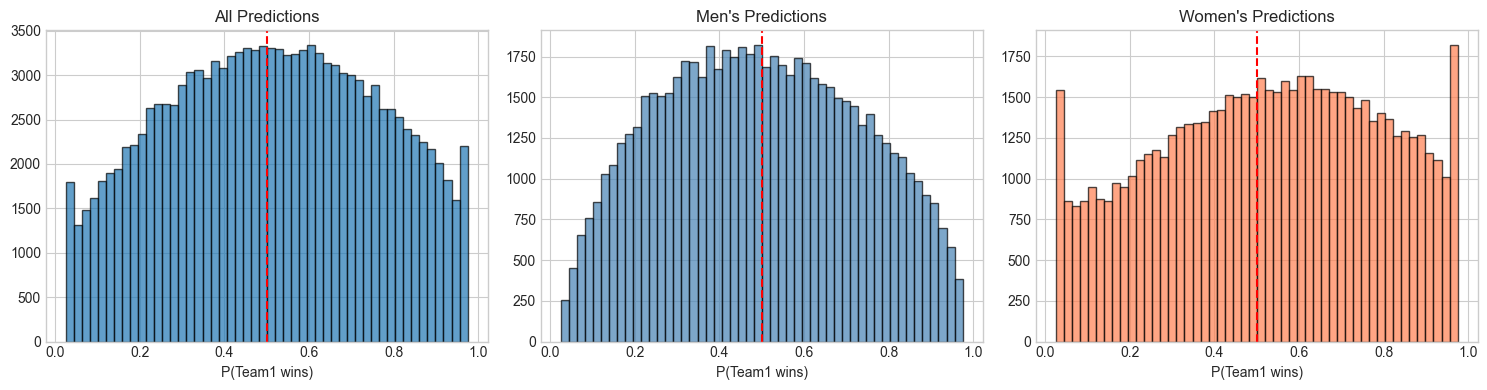


Submission stats:
  Mean: 0.5113
  Std:  0.2472
  Min:  0.0250
  Max:  0.9750


In [121]:
# Generate submission
sub = utils.parse_submission_ids(sample_sub)
sub_enriched = features.create_matchup_df(sub, FINAL_TEAM_FEATURES)
sub_enriched, _ = features.compute_difference_features(sub_enriched)

# Flag men's vs women's rows
sub_enriched['is_mens'] = ((sub_enriched['T1_TeamID'] < 3000) & (sub_enriched['T2_TeamID'] < 3000)).astype(int)

if SPLIT_MW:
    # Predict separately for M and W
    sub_preds = np.zeros(len(sub_enriched))
    
    men_mask = sub_enriched['is_mens'] == 1
    women_mask = sub_enriched['is_mens'] == 0
    
    # Men
    X_sub_m = sub_enriched.loc[men_mask, MEN_FEATURES].fillna(0).values
    if MEN_MODEL == 'logreg':
        X_sub_m = men_scaler.transform(X_sub_m)
        sub_preds[men_mask] = final_men_model.predict_proba(X_sub_m)[:, 1]
    elif MEN_MODEL == 'xgb':
        sub_preds[men_mask] = final_men_model.predict(xgb.DMatrix(X_sub_m))
    
    # Women
    X_sub_w = sub_enriched.loc[women_mask, WOMEN_FEATURES].fillna(0).values
    if WOMEN_MODEL == 'logreg':
        X_sub_w = women_scaler.transform(X_sub_w)
        sub_preds[women_mask] = final_women_model.predict_proba(X_sub_w)[:, 1]
    
    print(f"Men's predictions: {men_mask.sum():,} matchups")
    print(f"Women's predictions: {women_mask.sum():,} matchups")
    
else:
    X_sub = sub_enriched[FINAL_FEATURES].fillna(0).values
    X_sub = final_scaler.transform(X_sub)
    sub_preds = final_model.predict_proba(X_sub)[:, 1]

final_sub = utils.generate_submission(
    sub_preds, sample_sub, '../output/submission_refined.csv'
)

# Distribution check — split by gender
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(final_sub['Pred'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--')
axes[0].set_title('All Predictions')

men_ids = final_sub['ID'].apply(lambda x: int(x.split('_')[1]) < 3000)
axes[1].hist(final_sub.loc[men_ids, 'Pred'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0.5, color='red', linestyle='--')
axes[1].set_title("Men's Predictions")

axes[2].hist(final_sub.loc[~men_ids, 'Pred'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[2].axvline(x=0.5, color='red', linestyle='--')
axes[2].set_title("Women's Predictions")

for ax in axes:
    ax.set_xlabel('P(Team1 wins)')
plt.tight_layout()
plt.show()

print(f"\nSubmission stats:")
print(f"  Mean: {final_sub['Pred'].mean():.4f}")
print(f"  Std:  {final_sub['Pred'].std():.4f}")
print(f"  Min:  {final_sub['Pred'].min():.4f}")
print(f"  Max:  {final_sub['Pred'].max():.4f}")

In [122]:
# Spot-check marquee matchups — top 2026 teams
# Using gender='M'/'W' to avoid ambiguity for shared names
print("\n" + "="*60)
print("  2026 Matchup Predictions — Men's")
print("="*60)

men_matchups = [
    ('Auburn', 'Duke', 'M'),
    ('Houston', 'Tennessee', 'M'),
    ('Florida', 'Alabama', 'M'),
    ('Iowa St', 'Marquette', 'M'),
    ('Kansas', 'St John\'s', 'M'),
    ('Duke', 'Houston', 'M'),
]

for t1, t2, g in men_matchups:
    id1 = utils.team_id(t1, gender=g)
    id2 = utils.team_id(t2, gender=g)
    if id1 and id2:
        low, high = min(id1, id2), max(id1, id2)
        row = final_sub[final_sub['ID'] == f'2026_{low}_{high}']
        if len(row) > 0:
            p = row['Pred'].values[0]
            n1, n2 = utils.team_name(low), utils.team_name(high)
            winner = n1 if p > 0.5 else n2
            conf = max(p, 1-p)
            print(f"  {n1} vs {n2}: {winner} wins ({conf:.1%})")

print("\n" + "="*60)
print("  2026 Matchup Predictions — Women's")
print("="*60)

women_matchups = [
    ('South Carolina', 'UCLA', 'W'),
    ('Texas', 'LSU', 'W'),
    ('Notre Dame', 'Connecticut', 'W'),
    ('USC', 'South Carolina', 'W'),
]

for t1, t2, g in women_matchups:
    id1 = utils.team_id(t1, gender=g)
    id2 = utils.team_id(t2, gender=g)
    if id1 and id2:
        low, high = min(id1, id2), max(id1, id2)
        row = final_sub[final_sub['ID'] == f'2026_{low}_{high}']
        if len(row) > 0:
            p = row['Pred'].values[0]
            n1, n2 = utils.team_name(low), utils.team_name(high)
            winner = n1 if p > 0.5 else n2
            conf = max(p, 1-p)
            print(f"  {n1} vs {n2}: {winner} wins ({conf:.1%})")


  2026 Matchup Predictions — Men's
  Auburn vs Duke: Duke wins (66.7%)
  Houston vs Tennessee: Houston wins (62.9%)
  Alabama vs Florida: Florida wins (62.5%)
  Iowa St vs Marquette: Iowa St wins (79.7%)
  Kansas vs St John's: St John's wins (56.1%)
  Duke vs Houston: Duke wins (55.4%)

  2026 Matchup Predictions — Women's
  South Carolina vs UCLA: South Carolina wins (56.7%)
  LSU vs Texas: LSU wins (58.1%)
  Connecticut vs Notre Dame: Connecticut wins (88.8%)
  South Carolina vs USC: South Carolina wins (74.8%)


---
## Step 5: Export Models & Bracket App

Export trained models and team features to `models/` for the interactive bracket predictor app.

**To run the bracket app:**
```bash
python -m src.export_models   # Train & save models (if not already done)
streamlit run app.py           # Launch interactive bracket filler
```

In [123]:
# Export models for the bracket app
# This saves trained models + team features to models/ directory
from src.export_models import train_and_export
config = train_and_export()
print(f"\nFeatures: {config['features']}")
print(f"Ready to run: streamlit run app.py")

  TRAINING FINAL MODELS FOR BRACKET APP

[1/5] Loading data...
  Regular season: 174,206 games
  Tournament: 1,962 games
  Seeds: 4,370 entries

[2/5] Computing features...
  Team features: 11,969 team-seasons, 38 columns

[3/5] Building training matchups...
  Men's training games: 1001
  Women's training games: 961

[4/5] Training models...
  Men's model coefficients: {'Diff_seed': np.float64(-0.481), 'Diff_PointDiff': np.float64(0.202), 'Diff_OffEff': np.float64(0.091), 'Diff_WinPct': np.float64(-0.37), 'Diff_quality': np.float64(-0.088), 'Diff_Elo': np.float64(0.916)}
  Women's model coefficients: {'Diff_seed': np.float64(-0.99), 'Diff_PointDiff': np.float64(0.938), 'Diff_OffEff': np.float64(-0.017), 'Diff_WinPct': np.float64(-1.16), 'Diff_quality': np.float64(0.171), 'Diff_Elo': np.float64(1.474)}

[5/5] Saving artifacts...

  Saved to C:\Users\JonMa\OneDrive\portfolio\Madness\models/:
    config.json                    (0.5 KB)
    men_model.pkl                  (0.7 KB)
    men_s

---
## Summary & Decision Log

### What we tried and what worked

| # | Category | Experiments | Result |
|---|----------|-------------|--------|
| 1 | **Baseline** | Seed only (LR) | ~0.166 avg MSE — the floor |
| 2 | **Feature sets** | Top4, Top6, All Diff | Top4 is sufficient; more features = overfitting |
| 3 | **Model types** | LR, XGB (depth=2), LGBM | LR wins — dataset too small for trees |
| 4 | **Derived metrics** | Quality (GLM) | Marginal but consistent improvement |
| 5 | **Massey ordinals** | Men-only rankings | Hurts when NaN→0 pollutes women's data |
| 6 | **Additional features** | SOS, Shooting %, Regularization | Redundant with seed and OffEff |
| 7 | **Dynamic ratings** | Elo (game-by-game), Coach exp | **Elo is the strongest feature**; coach adds noise |
| 8 | **Split M/W** | Separate men/women models | Women much more predictable; split wins |

### Why simple beats complex
1. **~1,900 tournament games total (2010–2025)** — not enough signal for deep models
2. **The selection committee already did the ML** — seeds encode SOS, record, eye test
3. **MSE punishes overconfidence** — a conservative 0.6 prediction beats a wrong 0.9 prediction
4. **Feature differences are linear** — seed diff → win prob is nearly sigmoid-shaped, perfect for LogReg

### Why Elo works
- **Captures recency**: late-season losses hurt more than early-season ones
- **Weights opponent quality**: beating a 1600-Elo team > beating a 1300-Elo team
- **Carries over between seasons**: sustained excellence gets credit (75% carry-over)
- **Margin-of-victory aware**: blowouts count more (with `log(1+MOV)` diminishing returns)
- **Largest coefficient in both models**: Men (0.92), Women (1.47) — model's strongest signal

### Final model choice
- **Split M/W with LogReg on Top4+Quality+Elo** — best validated approach (0.1604 avg MSE)
- Elo is the dominant feature (largest coefficient in both models)
- Women's games are more predictable (fewer upsets, larger talent gaps)
- Quality metric adds marginal but consistent signal via GLM team strength

### Bracket App
Run `streamlit run app.py` for an interactive bracket predictor:
- Auto-fill brackets using trained models (deterministic or probabilistic)
- Manual overrides for any game
- Head-to-head matchup explorer with win probabilities
- Works with any past season or the 2026 tournament (once seeds are released)

### To continue improving
- Re-run when 2026 seeds are released (Selection Sunday)
- Consider conference tournament results as a momentum signal
- Test interaction features (e.g., seed × Elo for men vs women)
- Explore Bayesian model averaging across top-3 experiments
- **Always validate on 3+ holdout years — single-year wins are noise**